In [3]:
import os
import numpy as np
import pandas as pd

from sklearn.metrics import (r2_score)
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib as mpl


In [4]:
os.getcwd()

'/Users/nadav/Dropbox/lastChance/whyScoresAreDifferent/githubRepository/contentVsForm/src'

In [5]:
FIG_SIZE = (12,6)
SAVE_DIR = "../../output/"

K_LABELS = {
    0: "Original text",
    1: "SAT 1",
    2: "SAT 2",
    3: "SAT 3",
    4: "SAT 4",
    5: "SAT 5",
    6: "SAT 6",
    7: "Standard GPT"
}

In [35]:
# The original full dataset processed + its embeddings
df_persuade = pd.read_csv("../../data/persuade/persuade_full_cleaned.csv")
full_embeddings = np.load("../../data/embeddings/embeddings_full.npy")

# the low and high scorer output datasets + their embeddings
# df_low_scorer = pd.read_csv("../../model/run_01/data_low_scored.csv") XX?
# df_high_scorer = pd.read_csv("../../model/run_01/data_high_scored.csv") XX?

low_embeddings = np.load("../../data/embeddings/embeddings_low_v2.npy") #XX? changed to vs 
high_embeddings = np.load("../../data/embeddings/embeddings_high_v2.npy") #XX? changed to vs 

# The results of the scorer run
results_df = pd.read_csv("../../data/results/sat_full/data_sat_scored.csv")

# The decomposition results
df_decomp = pd.read_csv("../../data/results/sat_full/decomp_rows_with_fe.csv", index_col=0)

-----

# Original Dataset Vizualizations

### Distribution of SES scores (Low x High)

In [7]:
out = (
    df_persuade
    .groupby(['economically_disadvantaged', 'holistic_essay_score'])
    .size()
    .reset_index(name='count')
)

out['share'] = out['count'] / out.groupby('economically_disadvantaged')['count'].transform('sum')

out

,economically_disadvantaged,holistic_essay_score,count,share
0,0,1,187,0.016823
1,0,2,1772,0.159410
2,0,3,3197,0.287603
3,0,4,3237,0.291202
4,0,5,2059,0.185228
5,0,6,664,0.059734
6,1,1,510,0.052888
7,1,2,2926,0.303433
8,1,3,3420,0.354661
9,1,4,1971,0.204397


In [34]:
0.1852284994602375 + 0.05973371716444764

0.24496221662468515

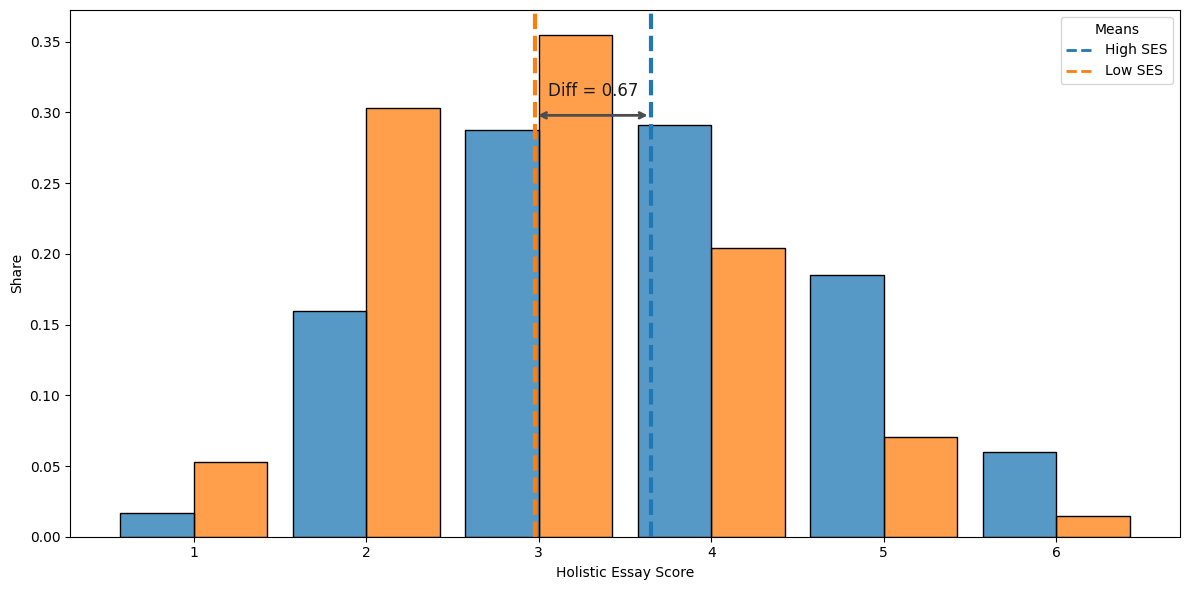

In [8]:
plt.figure(figsize=FIG_SIZE)

sns.histplot(
    data=df_persuade,
    x="holistic_essay_score",
    hue="economically_disadvantaged",
    bins=np.arange(0.5, 6.5 + 1, 1),
    stat="density",
    multiple="dodge",
    shrink=0.85,
    common_norm=False,
    palette={0: "tab:blue", 1: "tab:orange"},
    legend=False
)

mean_high = df_persuade.loc[df_persuade["economically_disadvantaged"] == 0, "holistic_essay_score"].mean()
mean_low  = df_persuade.loc[df_persuade["economically_disadvantaged"] == 1, "holistic_essay_score"].mean()

ax = plt.gca()
plt.axvline(mean_high, color="tab:blue", linestyle="--", linewidth=3)
plt.axvline(mean_low,  color="tab:orange", linestyle="--", linewidth=3)

mean_diff = mean_high - mean_low
y_max = ax.get_ylim()[1]
y_pos = y_max * 0.8

ax.annotate(
    "",
    xy=(mean_high, y_pos),
    xytext=(mean_low, y_pos),
    arrowprops=dict(arrowstyle="<->", color="0.3", lw=2)
)
ax.text(
    (mean_high + mean_low) / 2,
    y_pos + y_max * 0.03,
    f"Diff = {mean_diff:.2f}",
    ha="center",
    va="bottom",
    fontsize=12,
    color="0.1"
)

plt.legend(
    handles=[
        Line2D([0], [0], color="tab:blue", linestyle="--", lw=2, label="High SES"),
        Line2D([0], [0], color="tab:orange", linestyle="--", lw=2, label="Low SES")
    ],
    title="Means"
)


plt.xlabel("Holistic Essay Score")
plt.ylabel("Share")
plt.savefig(SAVE_DIR + "real_scores.pdf")
plt.tight_layout()
plt.show()


### Mean score distribuition - by prompts (questions)

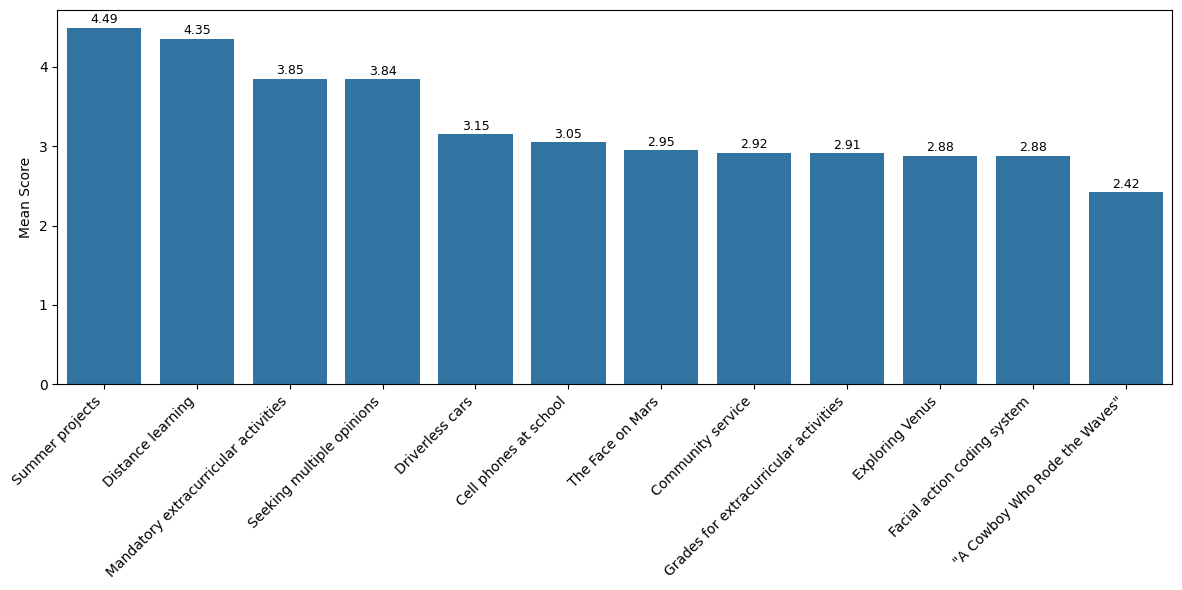

In [9]:
# --- Mean table ---
mean_table = (
    df_persuade.groupby("prompt_name")["holistic_essay_score"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("holistic_essay_score", ascending=False)
)

# --- Plot ---
plt.figure(figsize=FIG_SIZE)
sns.barplot(
    data=mean_table,
    x="prompt_name",
    y="holistic_essay_score",
)

# Add value labels on top of bars
for i, row in enumerate(mean_table.itertuples()):
    plt.text(
        i, row.holistic_essay_score + 0.02,  # small offset
        f"{row.holistic_essay_score:.2f}",
        ha="center", va="bottom", fontsize=9
    )

plt.xlabel("")
plt.ylabel("Mean Score")
plt.xticks(rotation=45, ha="right")
plt.savefig(SAVE_DIR + "mean_score_prompts.pdf")
plt.tight_layout()
plt.show()

### Scatterplot Matrix for predicted scores (only on original essays)

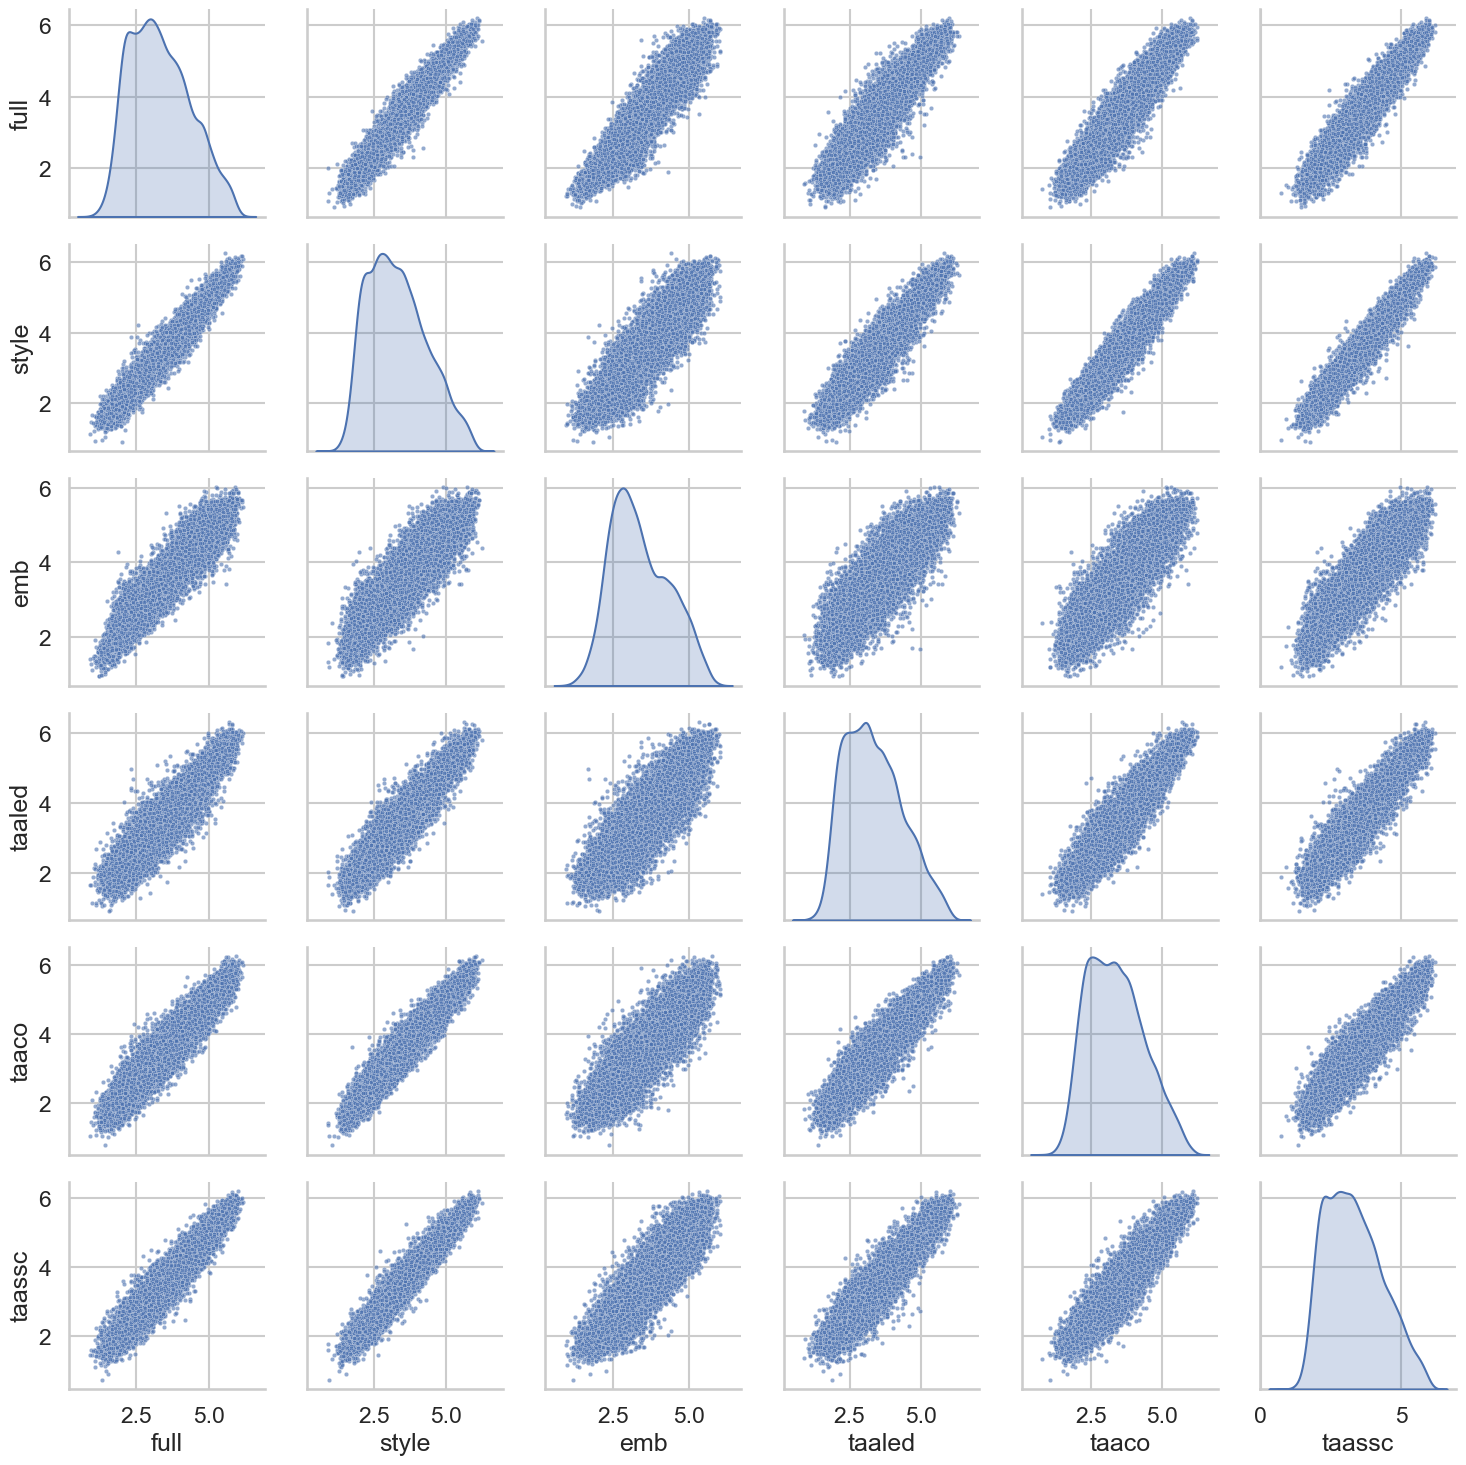

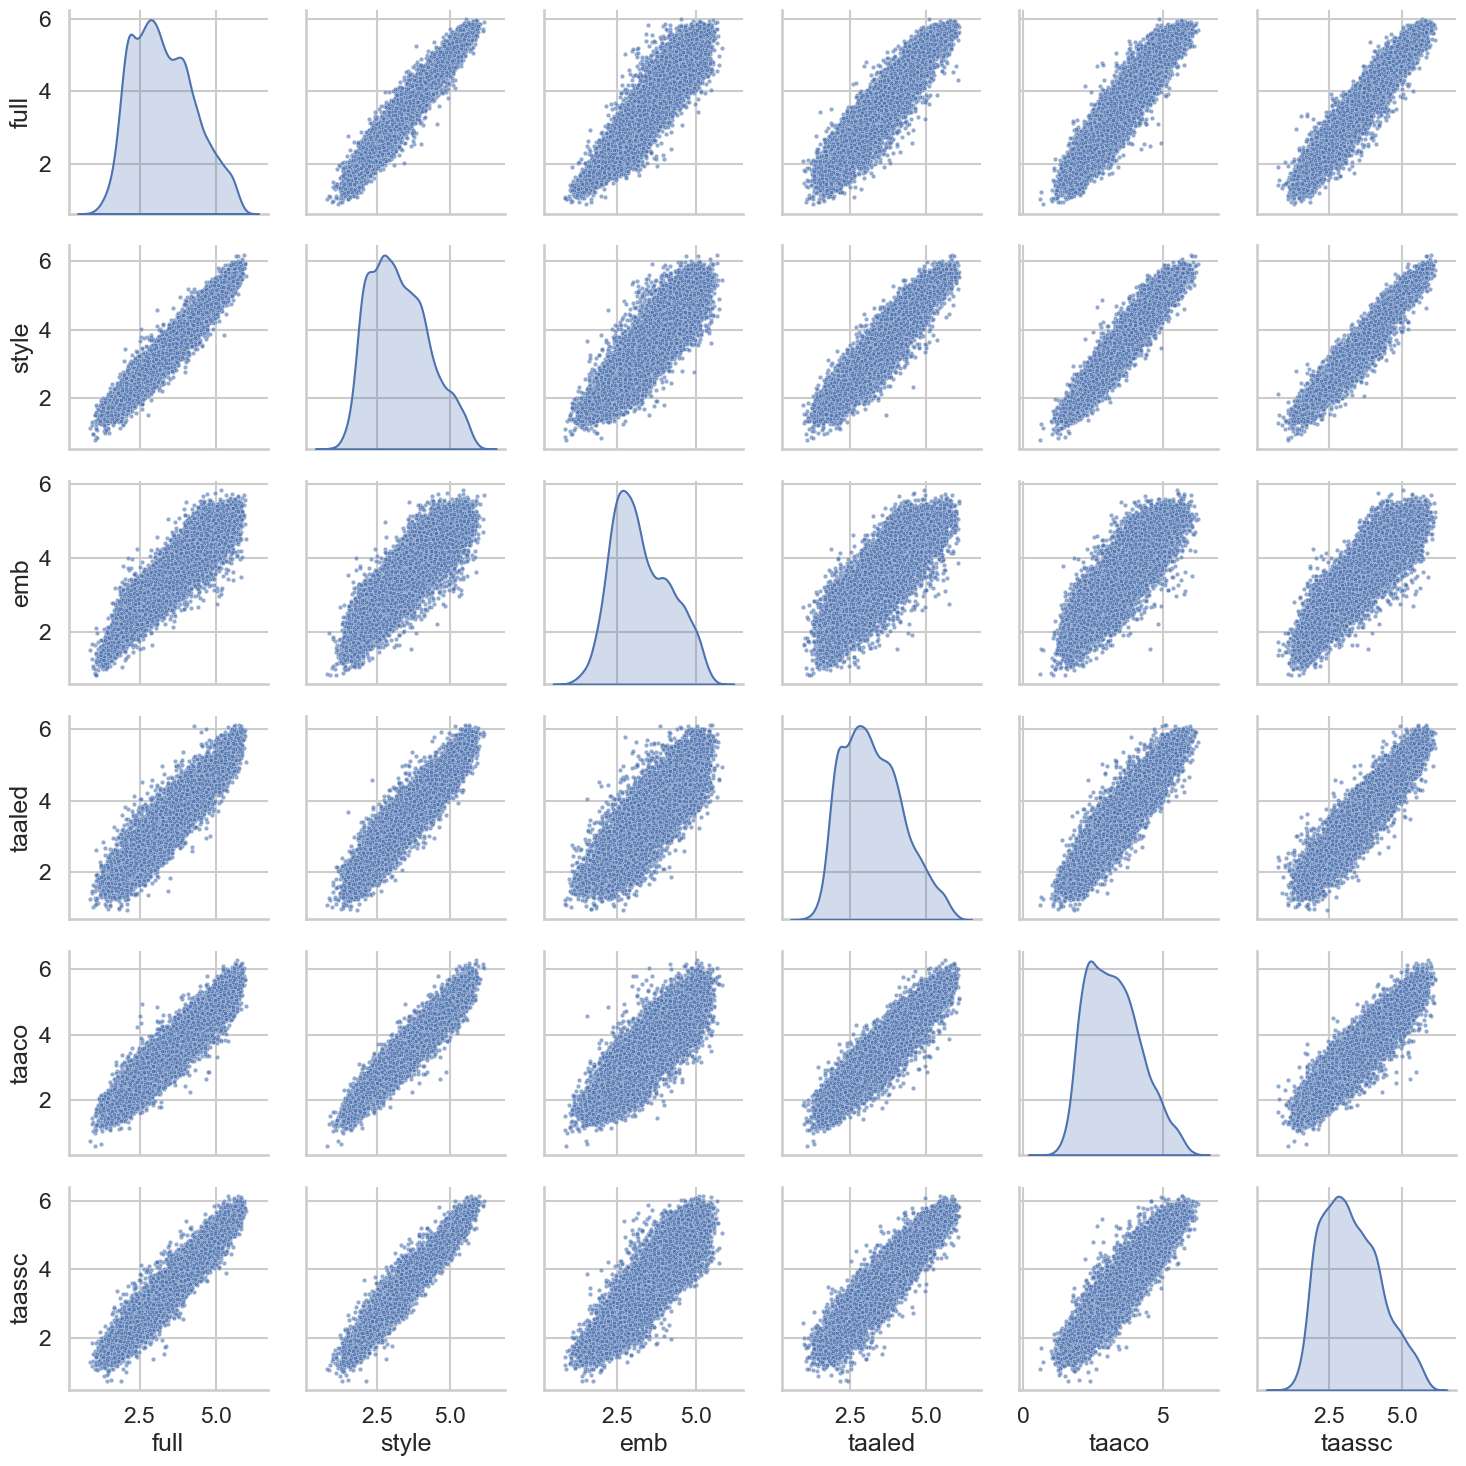

In [10]:
filtered = results_df[results_df["k"] == 0]

high_cols = [c for c in filtered.columns if c.startswith("score_high")]
low_cols  = [c for c in filtered.columns if c.startswith("score_low")]

def rename_cols(cols):
    return {c: c.split("_")[-1] for c in cols}

sns.set(style="whitegrid", context="talk")

# ---- High SES ----
high_df = filtered[high_cols].rename(columns=rename_cols(high_cols))
g1 = sns.pairplot(high_df, diag_kind="kde", plot_kws=dict(s=10, alpha=0.6))
plt.savefig(f"{SAVE_DIR}scatter_matrix_high_ses.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

# ---- Low SES ----
low_df = filtered[low_cols].rename(columns=rename_cols(low_cols))
g2 = sns.pairplot(low_df, diag_kind="kde", plot_kws=dict(s=10, alpha=0.6))
plt.savefig(f"{SAVE_DIR}scatter_matrix_low_ses.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

### Binned Values - predicted x estimated mean (Low SES)

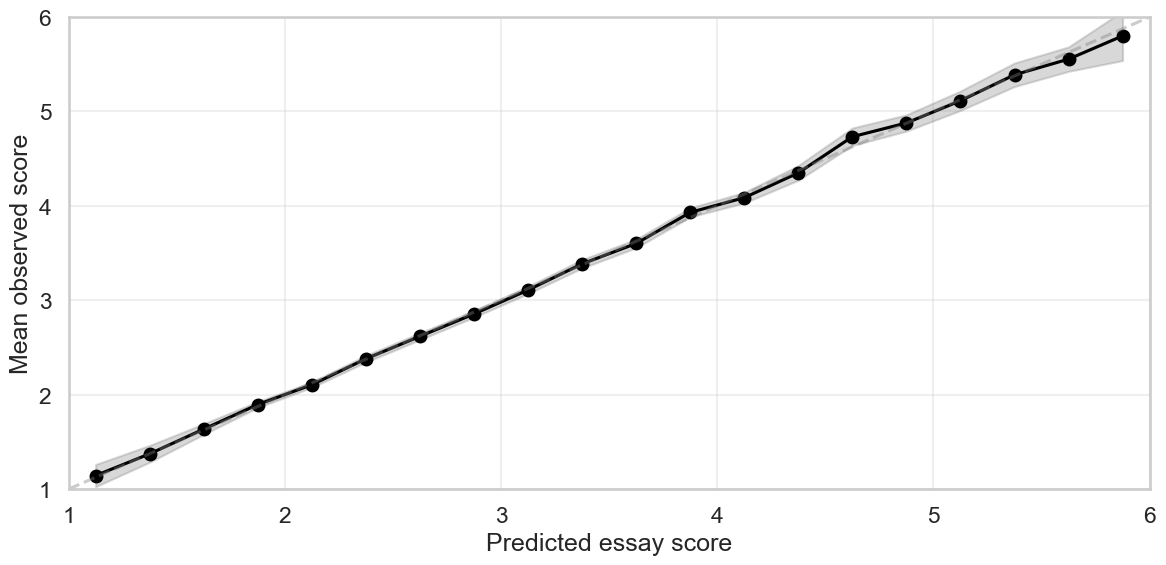

In [11]:
df_low = filtered.query("low_SES == 1").copy()

bins = np.linspace(1, 6, 21)
binned = pd.cut(df_low["score_low_full"], bins=bins, include_lowest=True, right=True)

stats = df_low.groupby(binned, observed=True)["true_score"].agg(["mean", "count", "std"])
stats["se"] = stats["std"] / np.sqrt(stats["count"])
stats.loc[stats["count"] <= 1, "se"] = np.nan
stats["ci"] = 1.96 * stats["se"]

centers = stats.index.map(lambda iv: (iv.left + iv.right) / 2).astype(float)
mask = stats["count"] >= 10

plt.figure(figsize=FIG_SIZE)
plt.plot(centers[mask], stats["mean"][mask], marker="o", color="black")
plt.fill_between(
    centers[mask],
    stats["mean"][mask] - stats["ci"][mask],
    stats["mean"][mask] + stats["ci"][mask],
    alpha=0.3, color="gray"
)
plt.plot([1, 6], [1, 6], "--", alpha=0.4, color="gray")
plt.xlim(1, 6); plt.ylim(1, 6)
plt.xlabel("Predicted essay score"); plt.ylabel("Mean observed score")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{SAVE_DIR}binned_low.pdf")
plt.show()

### Binned Values - predicted x estimated mean (High SES)

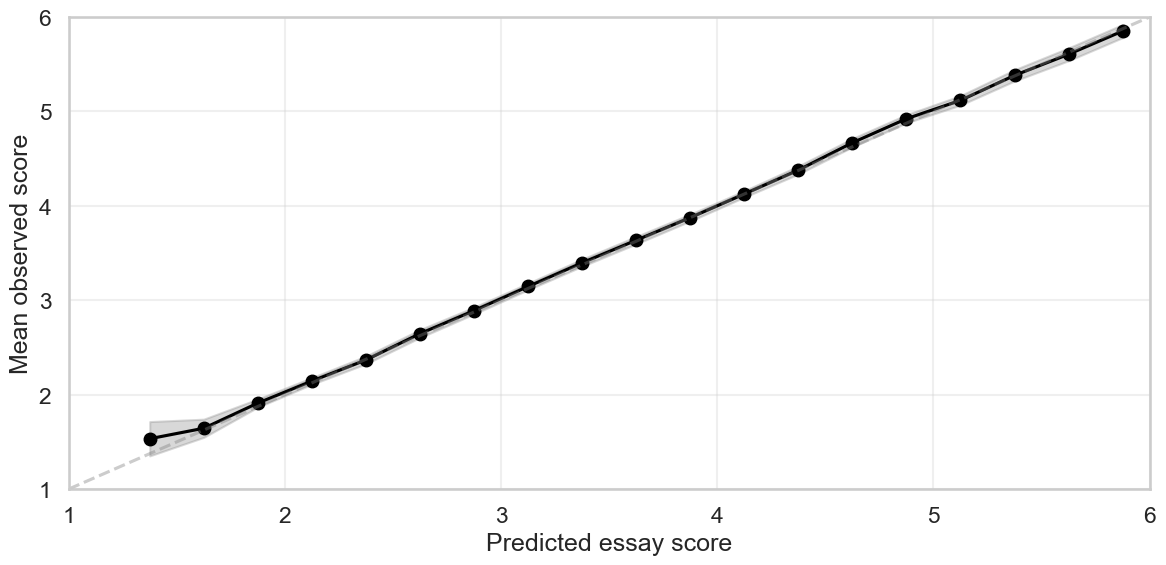

In [12]:
# Compact binned calibration plot (high SES only)
df_high = filtered.query("low_SES == 0").copy()

bins = np.linspace(1, 6, 21)
binned = pd.cut(df_high["score_high_full"], bins=bins, include_lowest=True, right=True)

stats = df_high.groupby(binned, observed=True)["true_score"].agg(["mean", "count", "std"])
stats["se"] = stats["std"] / np.sqrt(stats["count"])
stats.loc[stats["count"] <= 1, "se"] = np.nan
stats["ci"] = 1.96 * stats["se"]

centers = stats.index.map(lambda iv: (iv.left + iv.right) / 2).astype(float)
mask = stats["count"] >= 10  # keep bins with enough data

plt.figure(figsize=FIG_SIZE)
plt.plot(centers[mask], stats["mean"][mask], marker="o", color="black")
plt.fill_between(
    centers[mask],
    stats["mean"][mask] - stats["ci"][mask],
    stats["mean"][mask] + stats["ci"][mask],
    alpha=0.3, color="gray"
)
plt.plot([1, 6], [1, 6], "--", alpha=0.4, color="gray")
plt.xlim(1, 6); plt.ylim(1, 6)
plt.xlabel("Predicted essay score"); plt.ylabel("Mean observed score")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{SAVE_DIR}binned_high.pdf")
plt.show()

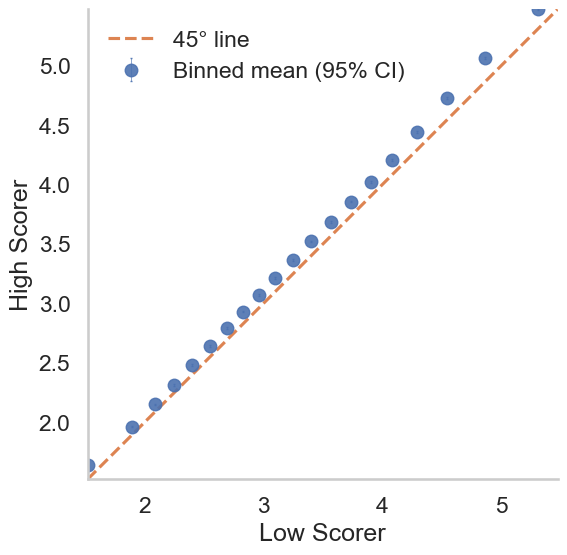

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = results_df['score_low_full']
y = results_df['score_high_full']

n_bins = 20
z = 1.96  # 95% CI

df = pd.DataFrame({'x': x, 'y': y}).dropna()

# Quantile (equal-count) bins
df['bin'] = pd.qcut(df['x'], q=n_bins, labels=False, duplicates='drop')

binned = (
    df.groupby('bin')
      .agg(
          x_mean=('x', 'mean'),
          y_mean=('y', 'mean'),
          y_std=('y', lambda s: s.std(ddof=1)),
          n=('y', 'size')
      )
      .reset_index()
)

binned['y_se'] = binned['y_std'] / np.sqrt(binned['n'])
binned['y_ci'] = z * binned['y_se']

plt.figure(figsize=(6, 6))

# Binned means with 95% CI
plt.errorbar(
    binned['x_mean'],
    binned['y_mean'],
    yerr=binned['y_ci'],
    fmt='o',
    capsize=1,
    elinewidth=0.5,
    alpha=0.9,
    label='Binned mean (95% CI)'
)

# 45-degree line
lims = [
    min(binned['x_mean'].min(), binned['y_mean'].min()),
    max(binned['x_mean'].max(), binned['y_mean'].max())
]
plt.plot(lims, lims, linestyle='--', label='45° line')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Low Scorer")
plt.ylabel("High Scorer")
plt.gca().set_aspect('equal', adjustable='box')

plt.legend(frameon=False)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}highVsLowSESPredictor.pdf')
plt.show()

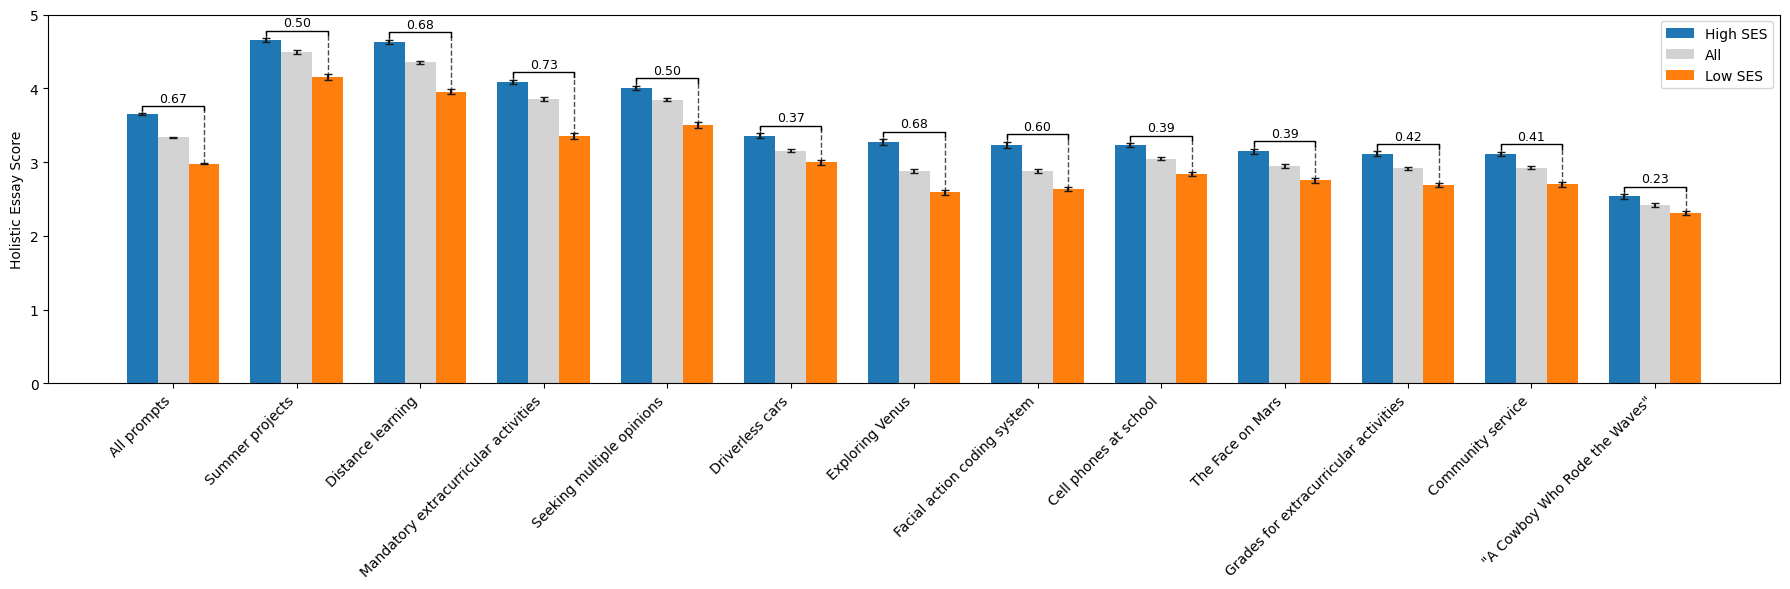

In [14]:
mpl.rcParams.update(mpl.rcParamsDefault)

df = df_persuade.copy()
df["holistic_essay_score"] = df["holistic_essay_score"].astype(float)

def agg(d):
    g = d.groupby("prompt_name")["holistic_essay_score"]
    return g.mean(), g.std() / np.sqrt(g.count())

high_mean, high_se = agg(df[df["economically_disadvantaged"] == 0])
low_mean,  low_se  = agg(df[df["economically_disadvantaged"] == 1])
all_mean,  all_se  = agg(df)

# --- NEW: add an "All prompts" column on the far left (aggregate over all prompts) ---
def overall_mean_se(d):
    y = d["holistic_essay_score"]
    return y.mean(), y.std(ddof=1) / np.sqrt(y.notna().sum())

H_m, H_se = overall_mean_se(df[df["economically_disadvantaged"] == 0])
L_m, L_se = overall_mean_se(df[df["economically_disadvantaged"] == 1])
A_m, A_se = overall_mean_se(df)

ALL_LABEL = "All prompts"

high_mean = pd.concat([pd.Series({ALL_LABEL: H_m}), high_mean])
high_se   = pd.concat([pd.Series({ALL_LABEL: H_se}), high_se])
low_mean  = pd.concat([pd.Series({ALL_LABEL: L_m}), low_mean])
low_se    = pd.concat([pd.Series({ALL_LABEL: L_se}), low_se])
all_mean  = pd.concat([pd.Series({ALL_LABEL: A_m}), all_mean])
all_se    = pd.concat([pd.Series({ALL_LABEL: A_se}), all_se])

# ---- sort prompts (excluding the new overall column), then put overall first ----
max_score = pd.concat([high_mean, low_mean, all_mean], axis=1).max(axis=1)
prompts_rest = max_score.drop(index=ALL_LABEL).sort_values(ascending=False).index
prompts = pd.Index([ALL_LABEL]).append(prompts_rest)

x = np.arange(len(prompts))
w = 0.25

fig, ax = plt.subplots(figsize=(18, 6))

ax.bar(x - w, high_mean.loc[prompts], w,
       yerr=high_se.loc[prompts], capsize=3, label="High SES")

ax.bar(x, all_mean.loc[prompts], w,
       yerr=all_se.loc[prompts], capsize=3, label="All", color="lightgray")

ax.bar(x + w, low_mean.loc[prompts], w,
       yerr=low_se.loc[prompts], capsize=3, label="Low SES")

# ---- brackets + dotted connectors ----
for i, p in enumerate(prompts):
    h = high_mean[p]
    l = low_mean[p]
    gap_val = h - l

    y = max(h + high_se[p], l + low_se[p]) + 0.10

    ax.plot([i-w, i-w], [h, y], linestyle="--", color="black", lw=1, alpha=0.7)
    ax.plot([i+w, i+w], [l, y], linestyle="--", color="black", lw=1, alpha=0.7)

    ax.plot([i-w, i-w, i+w, i+w],
            [y-0.06, y, y, y-0.06],
            color="black", lw=1)

    ax.text(i, y + 0.02, f"{gap_val:.2f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Holistic Essay Score")
# ax.set_xlabel("Prompts")
ax.set_xticks(x)
ax.set_xticklabels(prompts, rotation=45, ha="right")
ax.set_ylim(0, 5)
ax.legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}essay_score_by_prompt.pdf")
plt.show()

----

# Embeddings Visualizations

### 2d Embedding (High x Low) - t-SNE
* Generates the image w/ full data
* Generates the image divided by prompt names

In [15]:
X_tsne = TSNE(
    n_components=2, metric="cosine", perplexity=30,
    init="random", learning_rate="auto", random_state=42
).fit_transform(full_embeddings)

df_tsne = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "SES": np.where(df_persuade["economically_disadvantaged"], "Low SES", "High SES"),
    "prompt_name": df_persuade["prompt_name"].astype(str)
})

In [16]:
# --- Plot helper ---
palette_points = {"Low SES": "#7c3aed", "High SES": "#f97316"}

def plot_tsne(d, title=None, save_path=None):
    plt.figure(figsize=FIG_SIZE)
    sns.set_style("white")

    for label in ["Low SES", "High SES"]:
        dd = d[d["SES"] == label]
        if len(dd):
            plt.scatter(dd["x"], dd["y"], s=6, alpha=0.20, color=palette_points[label])

    for label, base_color in [("Low SES", "#7c3aed"), ("High SES", "#f97316")]:
        dd = d[d["SES"] == label]
        if len(dd) < 5:
            continue
        cmap = sns.light_palette(base_color, as_cmap=True)
        sns.kdeplot(data=dd, x="x", y="y", fill=True, thresh=0.02, levels=80, bw_adjust=1.0, alpha=0.75, cmap=cmap)
        sns.kdeplot(data=dd, x="x", y="y", fill=False, levels=7, bw_adjust=1.0, linewidths=1.1, cmap=cmap)

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    handles = [
        Line2D([0], [0], color="#f97316", lw=3, label="High SES"),
        Line2D([0], [0], color="#7c3aed", lw=3, label="Low SES"),
    ]
    plt.legend(handles=handles, frameon=True)

    if title: 
        plt.title(title)

    plt.tight_layout()

    if save_path:
        plt.savefig(SAVE_DIR + f"{save_path}.pdf", dpi=300)
    
    plt.show()

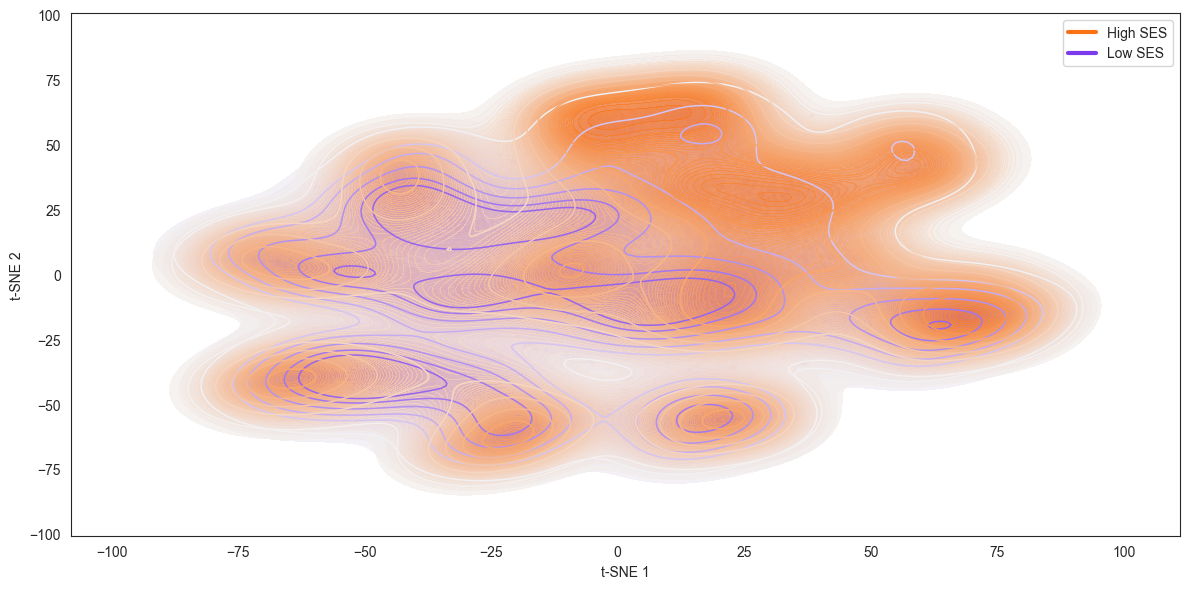

In [17]:
plot_tsne(df_tsne, save_path="t_sne_kde")

In [18]:
def plot_tsne_grid(
    df_tsne,
    rows=3,
    cols=5,
    save_path=None,

    title_fs=11,
    label_fs=10,
    tick_fs=9,
    legend_fs=11,

    point_size=8,
    point_alpha=0.25,
    kde_fill_alpha=0.70,
    kde_line_width=1.0,

    wspace=0.20,
    hspace=0.25,
    top_pad=0.90,
    bottom_pad=0.08,
    left_pad=0.06,
    right_pad=0.98,

    color_high="#f97316",
    color_low="#7c3aed",

    legend_loc="upper center",
    legend_bbox=(0.5, 1.02),   # x, y relative to figure
):

    palette_points = {
        "High SES": color_high,
        "Low SES":  color_low
    }

    # ------------------------
    # Internal function: plots a single t-SNE panel
    # ------------------------
    def plot_tsne_ax(d, ax, title=None):
        # scatter points
        for label in ["Low SES", "High SES"]:
            dd = d[d["SES"] == label]
            if len(dd):
                ax.scatter(
                    dd["x"], dd["y"],
                    s=point_size,
                    alpha=point_alpha,
                    color=palette_points[label]
                )

        # KDE layers
        for label, base_color in [("Low SES", color_low), ("High SES", color_high)]:
            dd = d[d["SES"] == label]
            if len(dd) >= 5 and dd[["x", "y"]].std().min() > 0:
                cmap = sns.light_palette(base_color, as_cmap=True)
                try:
                    sns.kdeplot(
                        data=dd, x="x", y="y",
                        fill=True, thresh=0.02,
                        bw_adjust=1.0,
                        alpha=kde_fill_alpha,
                        cmap=cmap, ax=ax
                    )
                    sns.kdeplot(
                        data=dd, x="x", y="y",
                        fill=False, levels=7,
                        bw_adjust=1.0,
                        linewidths=kde_line_width,
                        cmap=cmap, ax=ax
                    )
                except Exception:
                    pass

        ax.set_xlabel("t-SNE 1", fontsize=label_fs)
        ax.set_ylabel("t-SNE 2", fontsize=label_fs)
        ax.tick_params(labelsize=tick_fs)

        if title:
            ax.set_title(title, fontsize=title_fs)

    # ------------------------
    # Grid layout
    # ------------------------
    prompts = sorted(df_tsne["prompt_name"].unique())
    total_plots = rows * cols

    fig, axes = plt.subplots(rows, cols, figsize=(25, 15))
    axes = np.ravel(axes)

    # fill grid with prompts
    for i, p in enumerate(prompts[:total_plots]):
        d = df_tsne[df_tsne["prompt_name"] == p]
        plot_tsne_ax(d, ax=axes[i], title=p)

    # disable empty axes
    for j in range(len(prompts), total_plots):
        axes[j].axis("off")

    # shared legend
    handles = [
        Line2D([0], [0], color=color_high, lw=3, label="High SES"),
        Line2D([0], [0], color=color_low,  lw=3, label="Low SES"),
    ]

    fig.legend(
        handles=handles,
        loc=legend_loc,
        ncol=2,
        fontsize=legend_fs,
        frameon=True,
        bbox_to_anchor=legend_bbox
    )


    # adjust spacing
    fig.subplots_adjust(
        top=top_pad,
        bottom=bottom_pad,
        left=left_pad,
        right=right_pad,
        wspace=wspace,
        hspace=hspace
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()


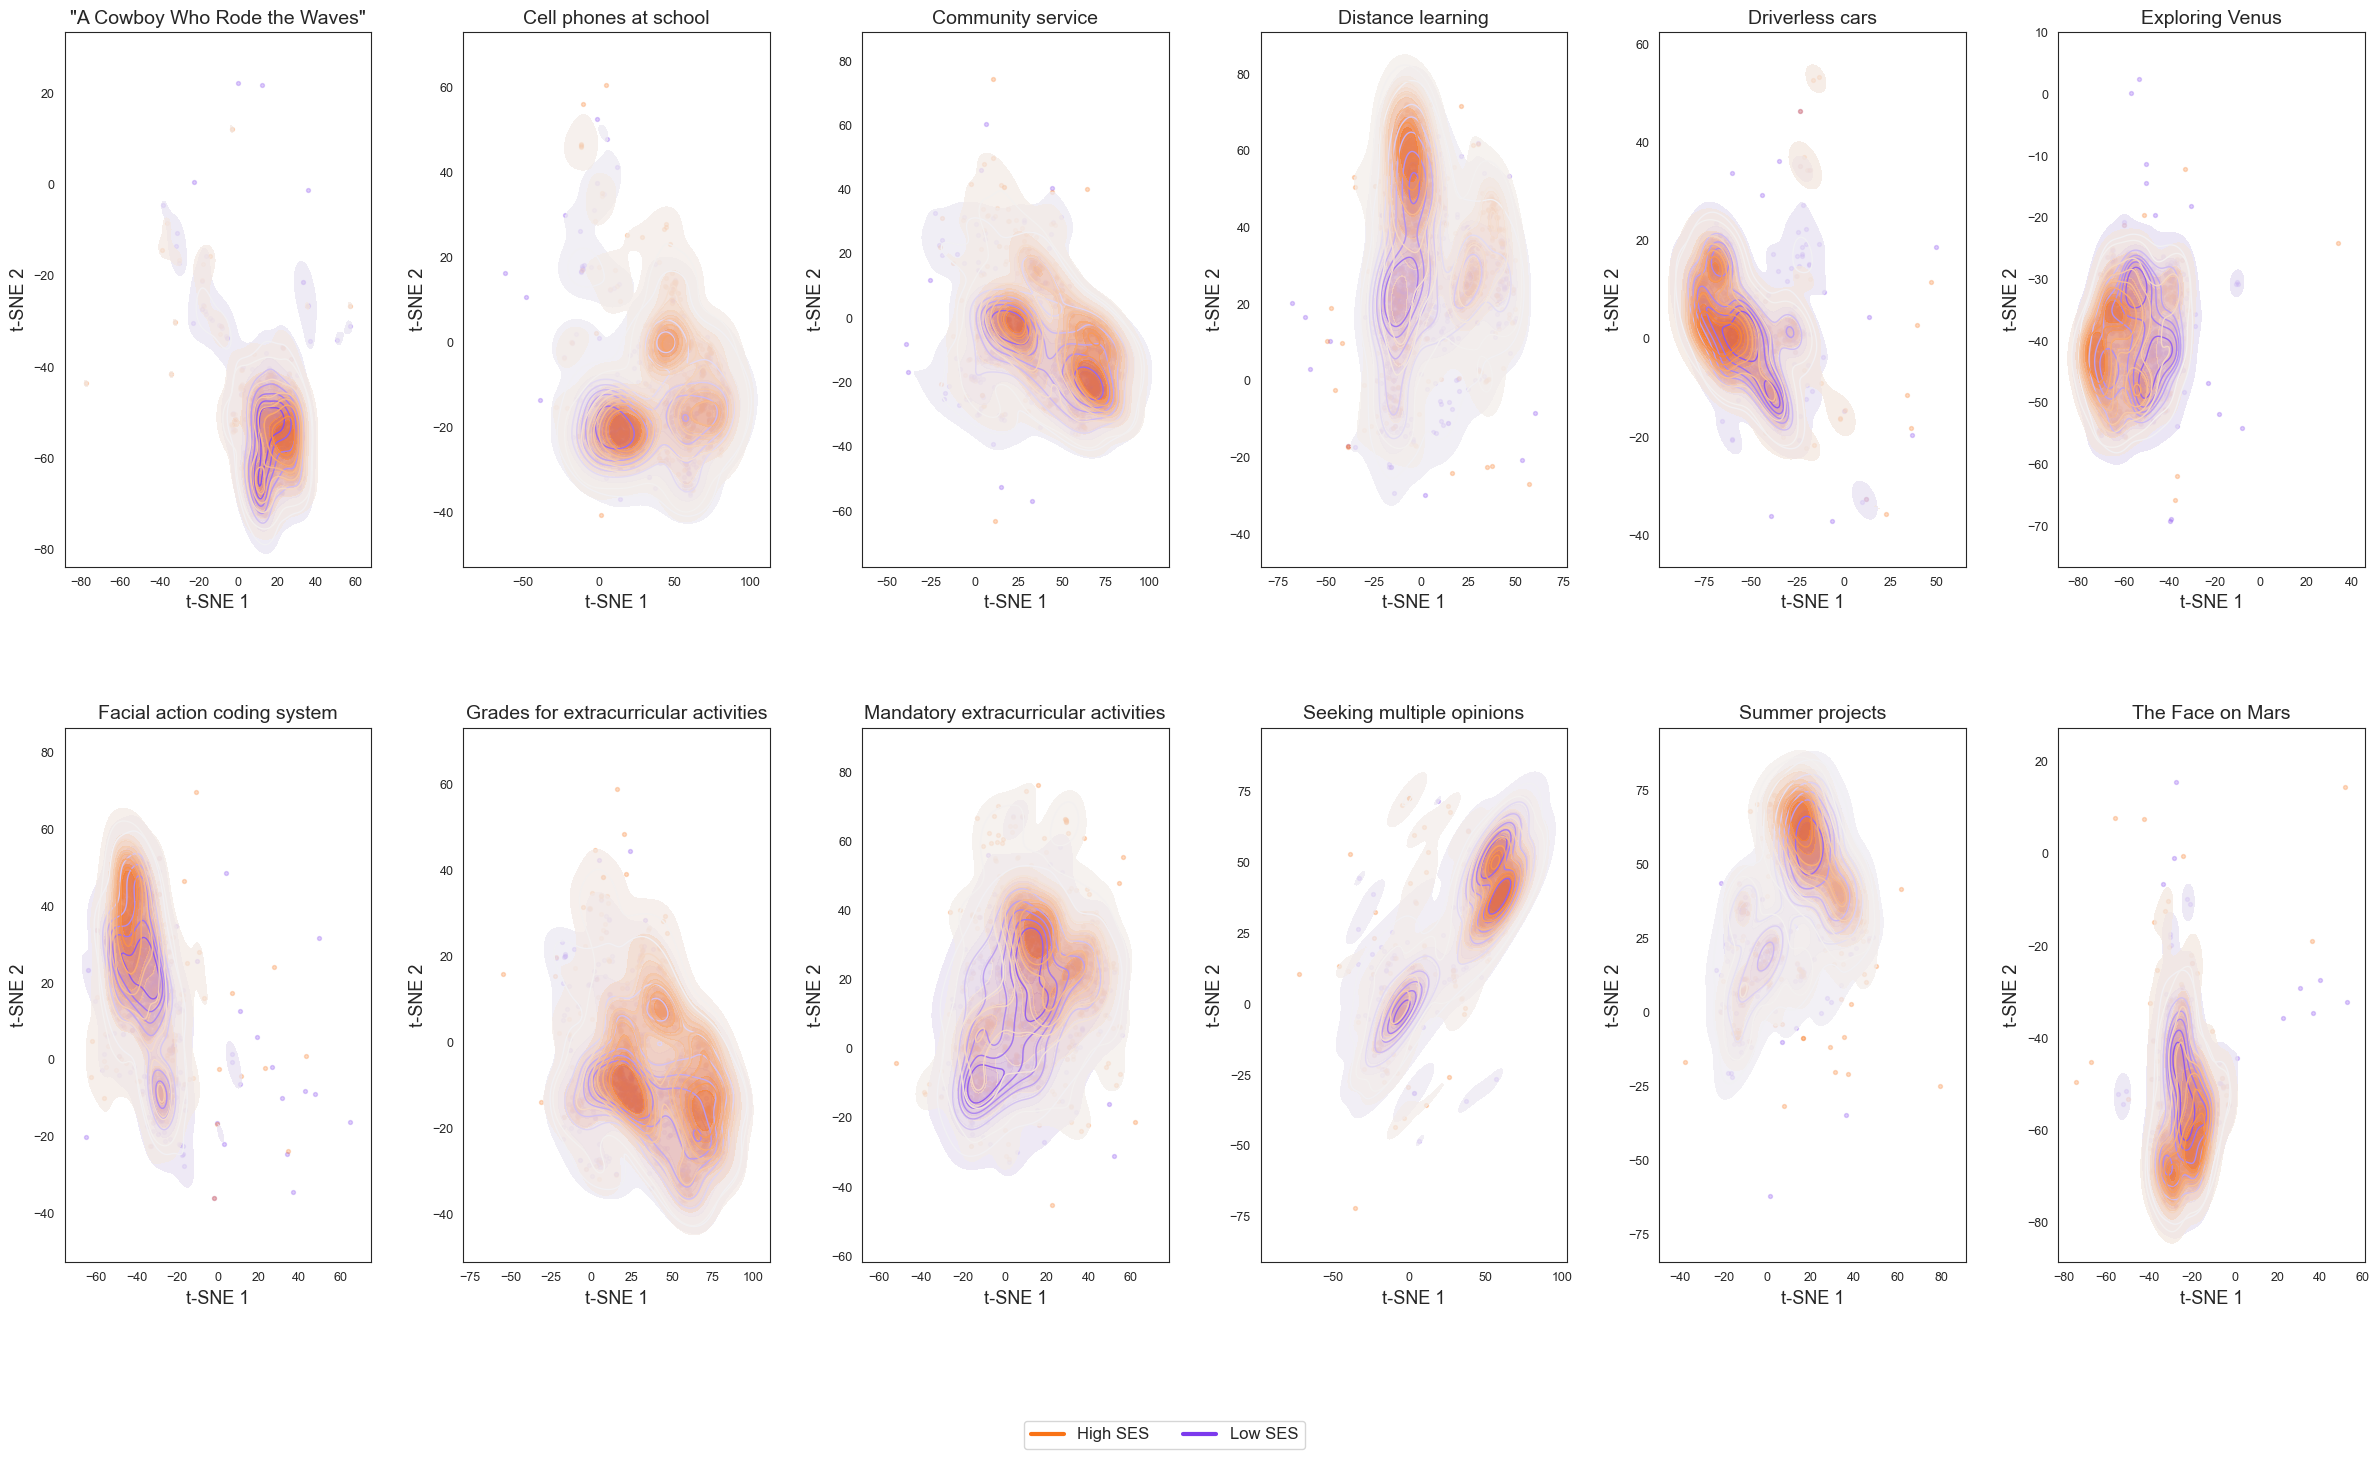

In [19]:
plot_tsne_grid(
    df_tsne,
    rows=2,
    cols=6,
    save_path=f"{SAVE_DIR}/tsne_grid.pdf",
    title_fs=14,
    label_fs=13,
    legend_fs=12, 
    wspace=0.30,
    hspace=0.30,

    legend_loc="lower center",
    legend_bbox=(0.5, -0.05)
)


### Distribution of predicted scores (Low x High)

----

In [20]:
# --- Overlayed histogram helper ---
def overlay_hist(df, col, label, save_name=None, save_dir=None):
    plt.figure(figsize=FIG_SIZE)
    bins = np.linspace(1, 6, 100)

    # High SES
    sns.histplot(
        data=df[df["low_SES"] == 0],
        x=col,
        bins=bins,
        stat="density", 
        element="step",
        fill=True,
        alpha=0.35,
        color="tab:blue",
        label="High SES",
        common_norm=False
    )

    # Low SES
    sns.histplot(
        data=df[df["low_SES"] == 1],
        x=col,
        bins=bins,
        stat="density",  
        element="step",
        fill=True,
        alpha=0.35,
        color="tab:orange",
        label="Low SES",
        common_norm=False
    )

    plt.xlim(1, 6)
    plt.xlabel(f"Predicted Essay Score ({label})")
    plt.ylabel("Density") 
    plt.legend()
    plt.tight_layout()

    if save_name:
        plt.savefig(save_dir + f"{save_name}.pdf")

    plt.show()
    plt.close()

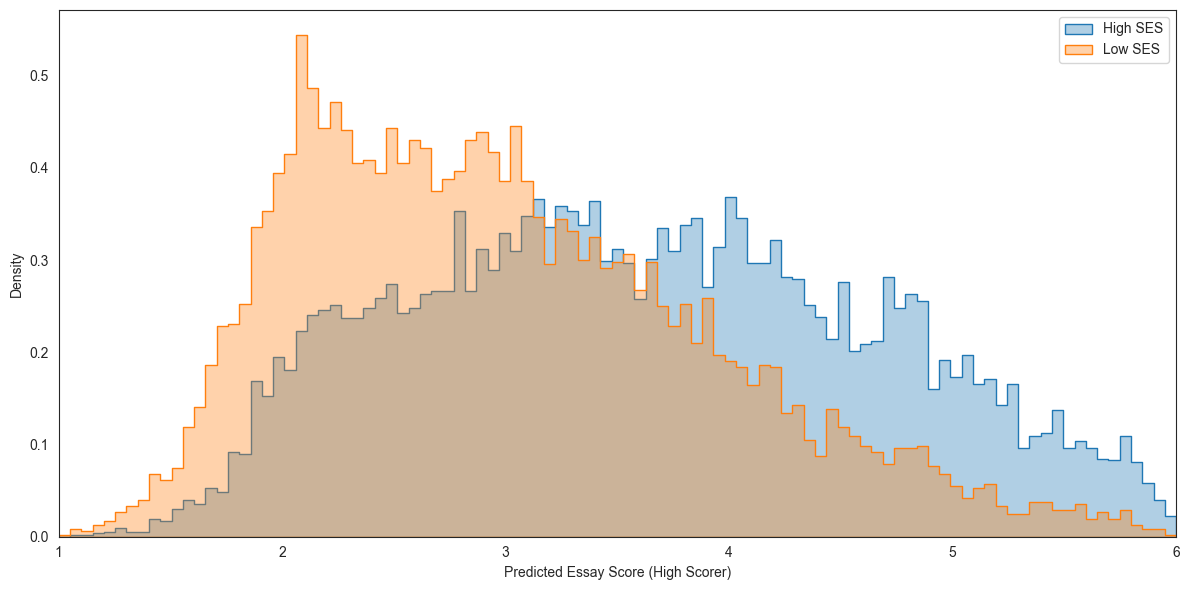

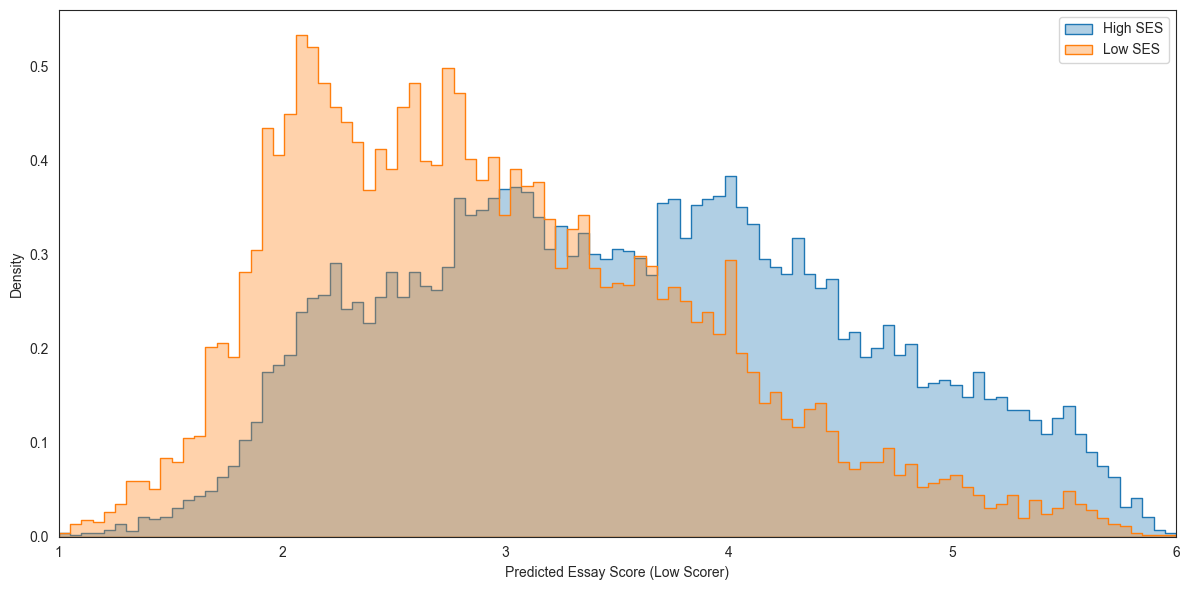

In [21]:
# --- Plots ---
overlay_hist(results_df[results_df['k']==0], col="score_high_full", label="High Scorer", save_name="predicted_score_high_scorer", save_dir=SAVE_DIR)
overlay_hist(results_df[results_df['k']==0], col="score_low_full",  label="Low Scorer", save_name="predicted_score_low_scorer", save_dir=SAVE_DIR)

### Distribution of predicted scores (Low x High) 
* Style 
* Embedding
* TAASSC
* TAACO
* TAALED
* PREPROC

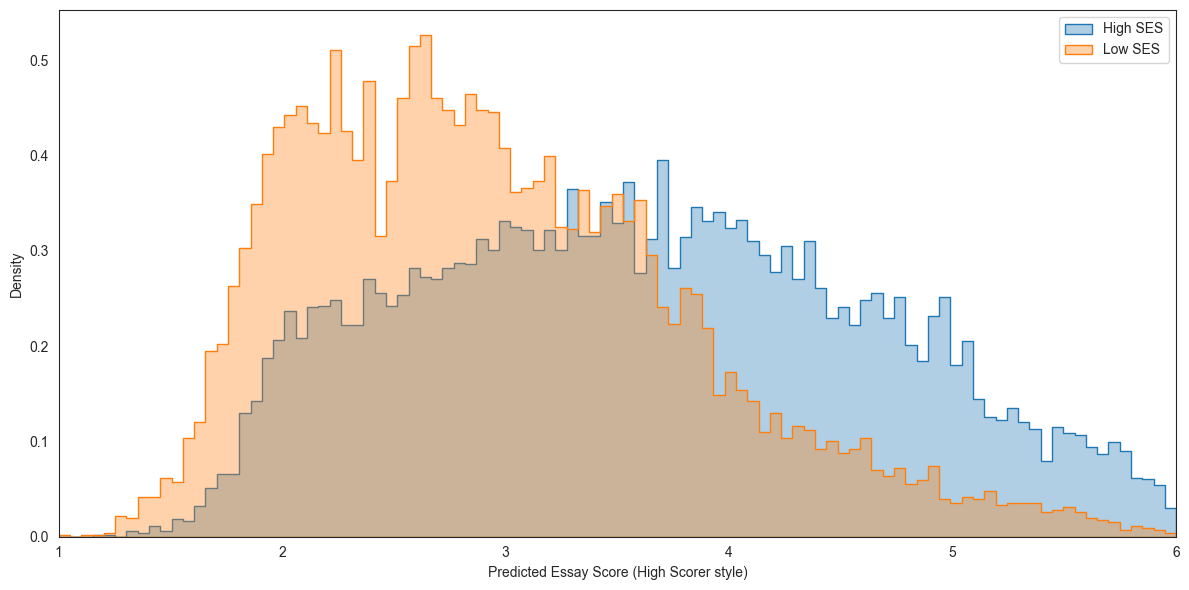

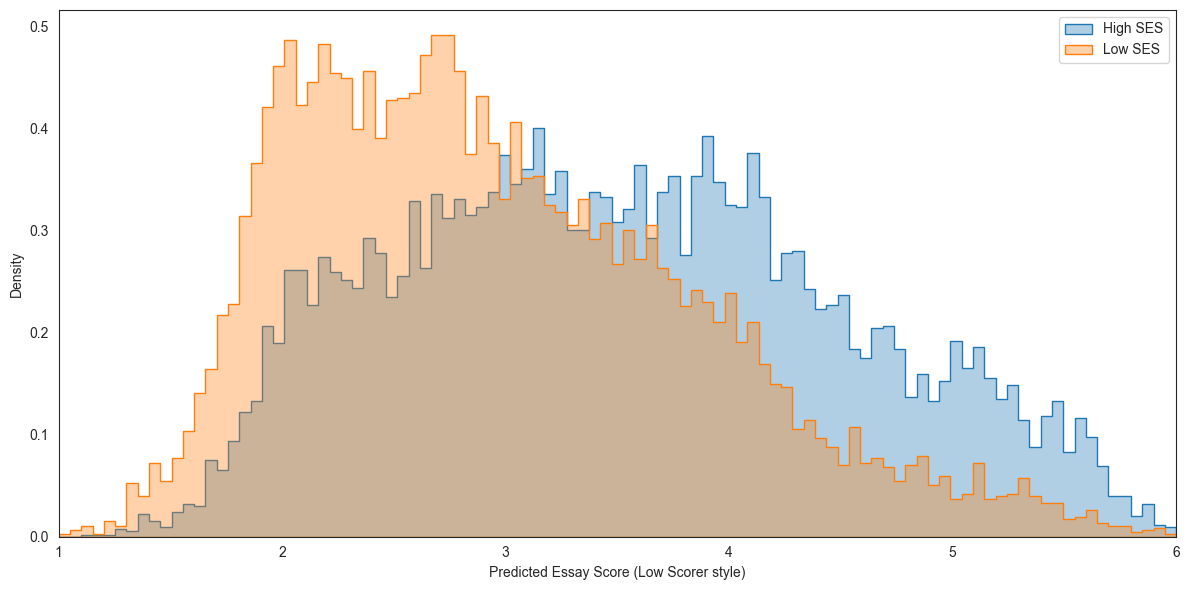

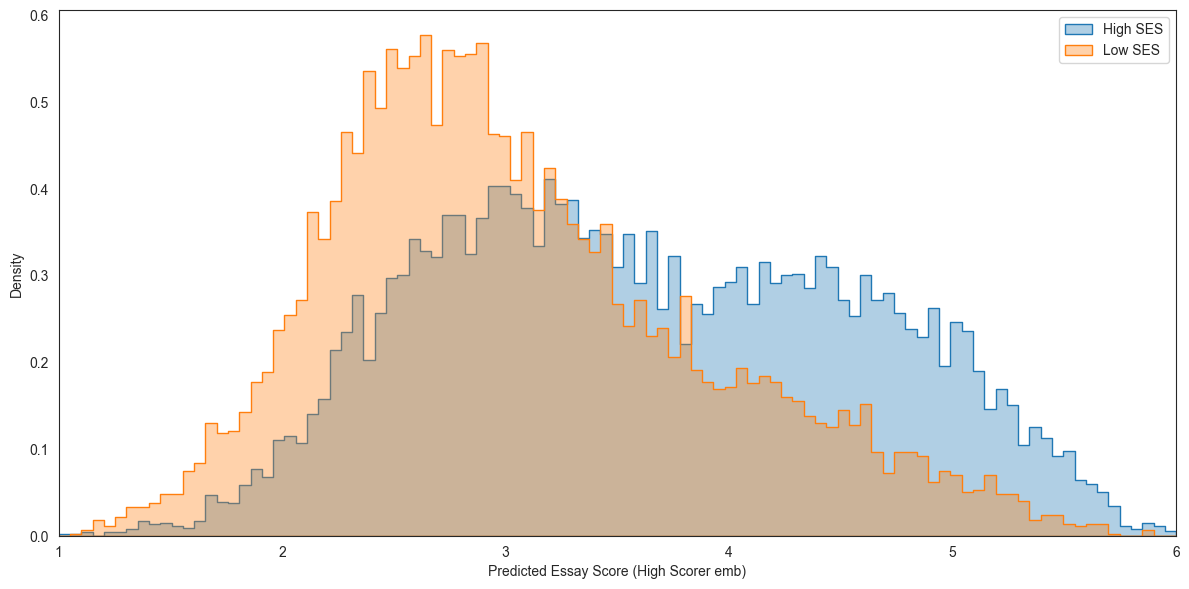

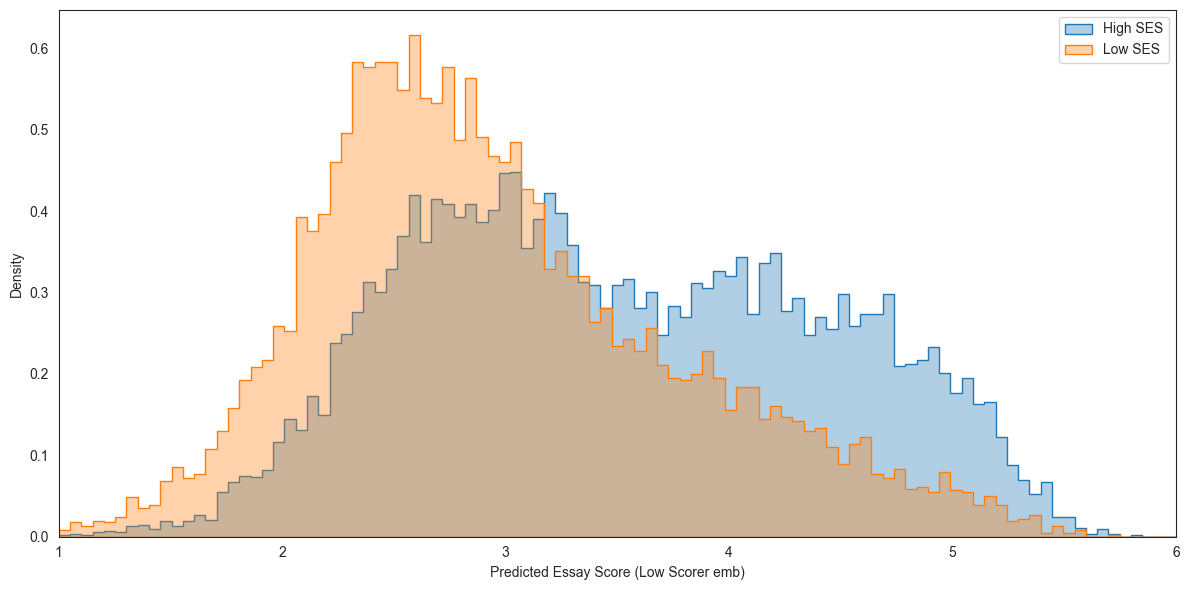

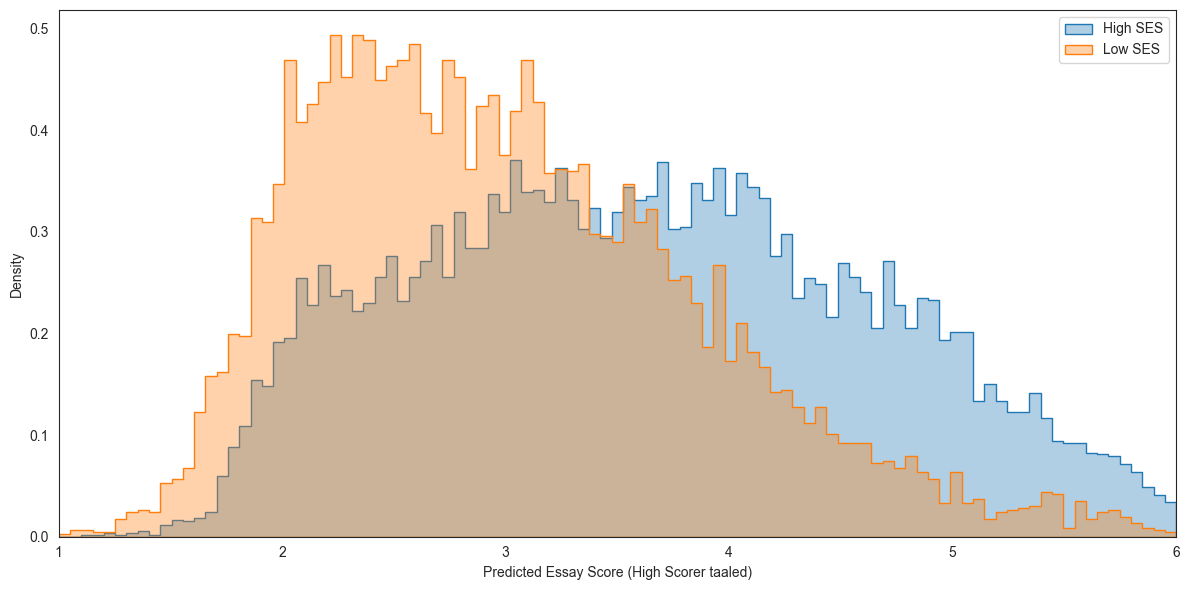

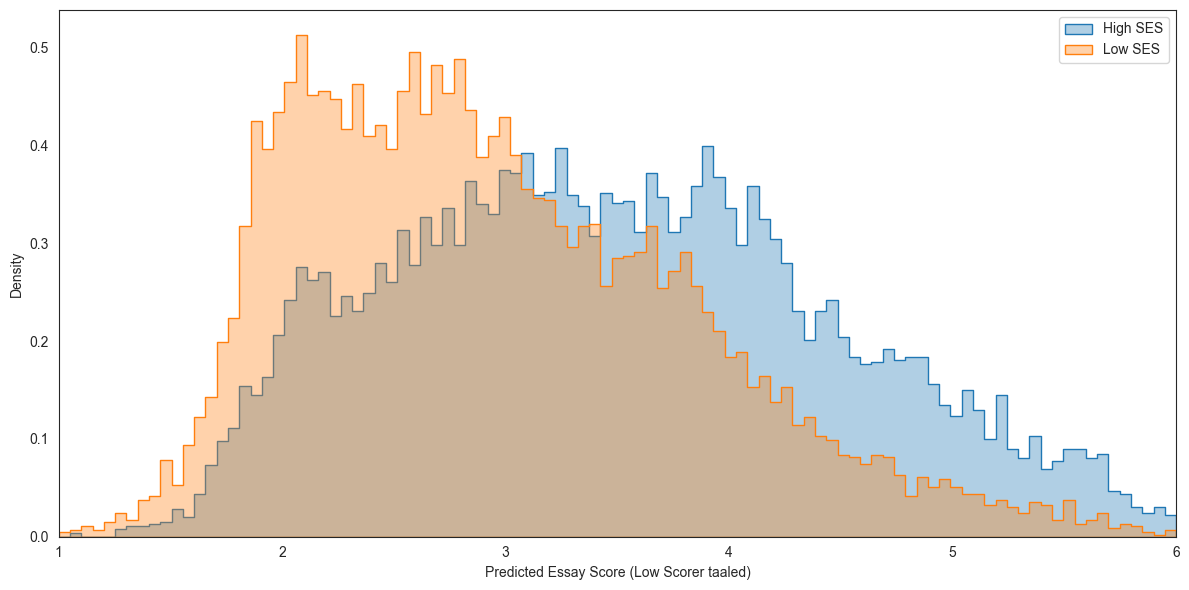

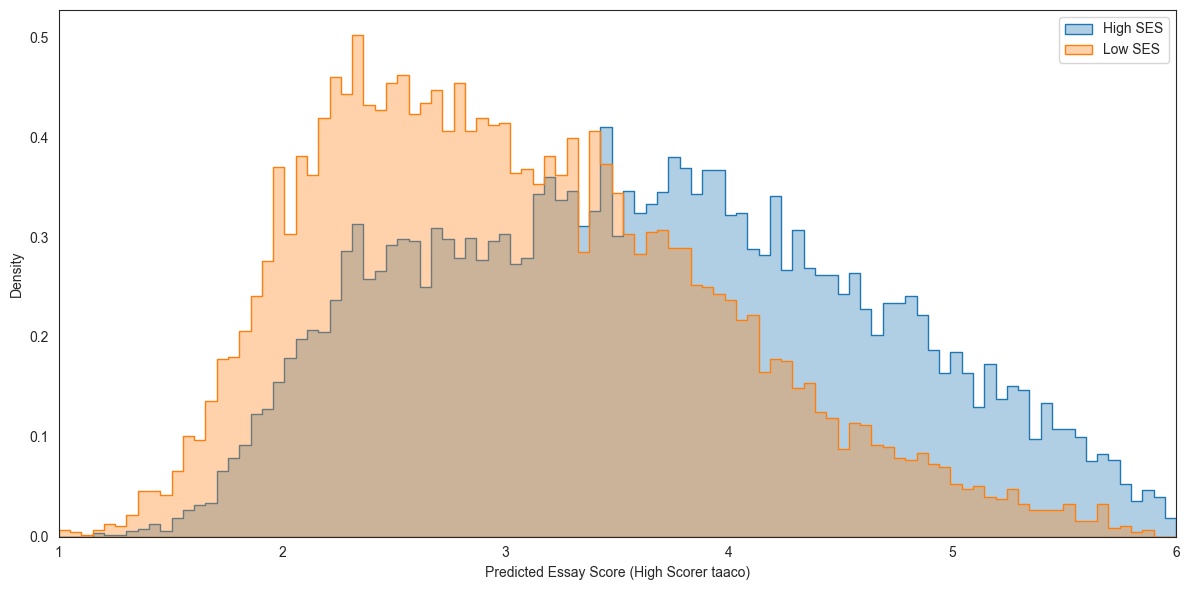

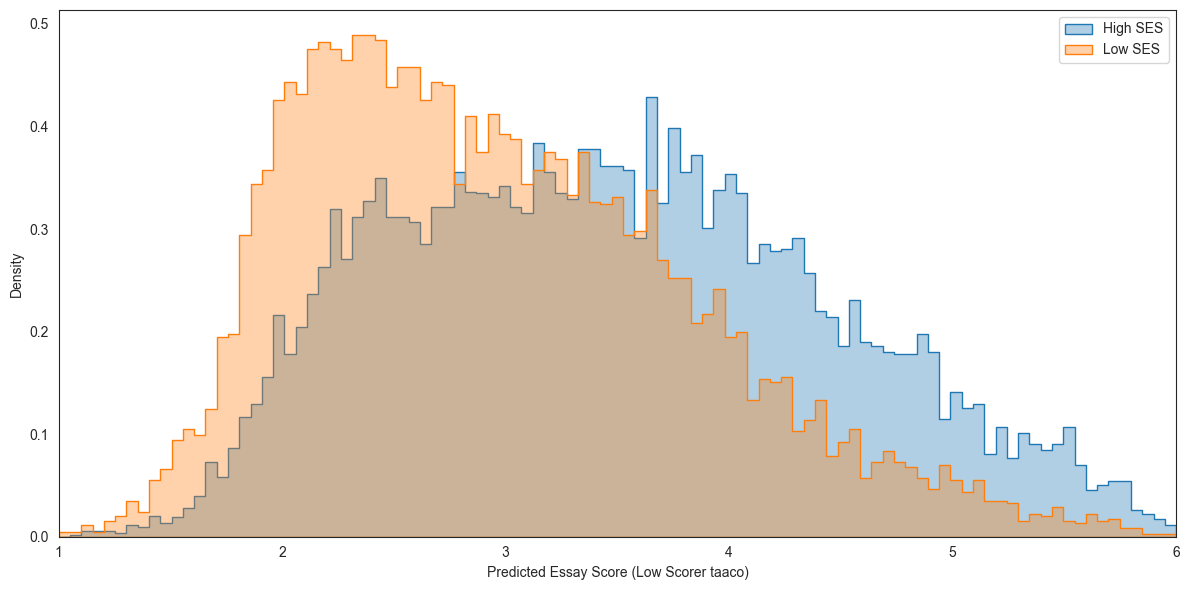

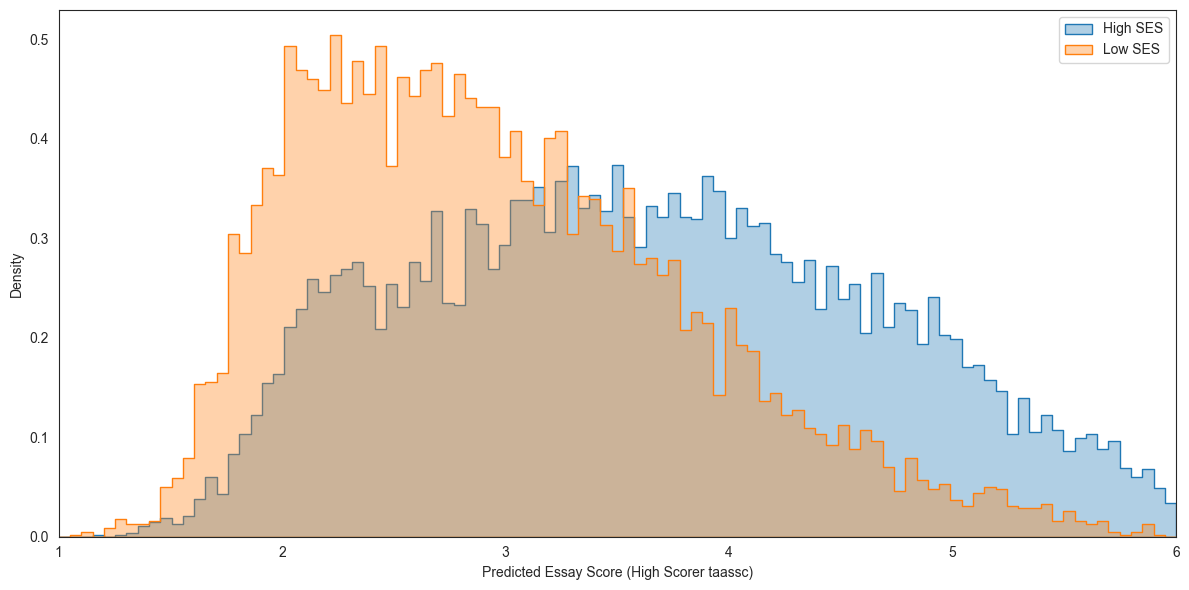

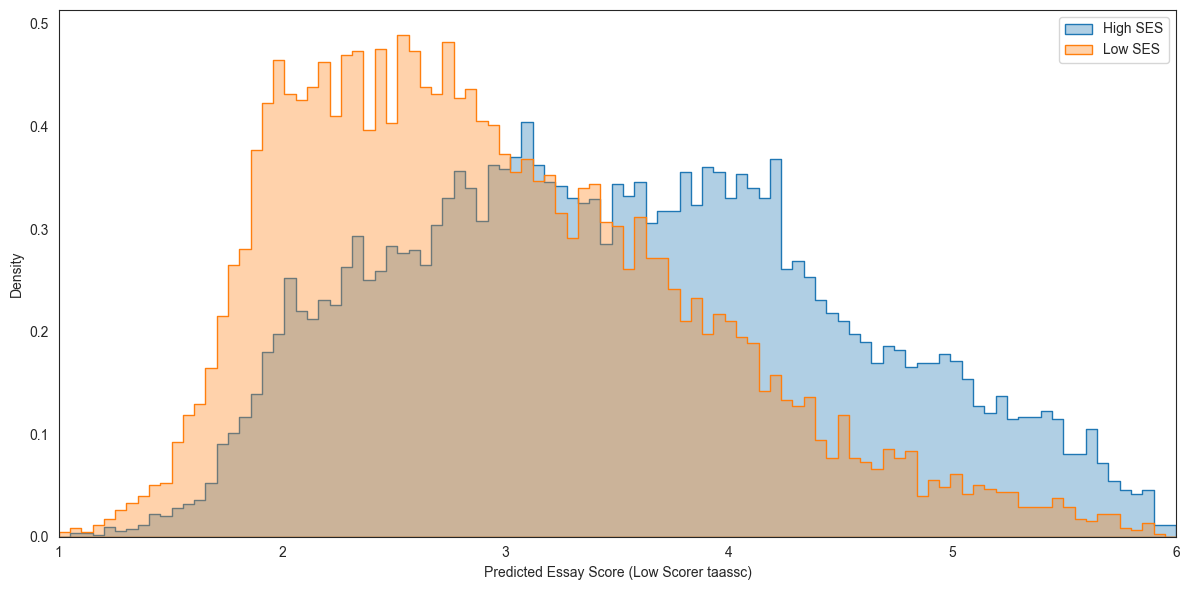

In [22]:
df_plot = results_df[results_df['k']==0].copy()
df_plot["SES"] = np.where(df_plot["low_SES"] == 1, "Low SES", "High SES")

for evals in ["style", "emb", "taaled", "taaco", "taassc"]:
    overlay_hist(df_plot, col=f"score_high_{evals}", label=f"High Scorer {evals}", save_name=f"predicted_score_high_scorer_{evals}",save_dir=SAVE_DIR)
    overlay_hist(df_plot, col=f"score_low_{evals}",  label=f"Low Scorer {evals}", save_name=f"predicted_score_low_scorer_{evals}",save_dir=SAVE_DIR)

# Rewrites Visualizations

In [23]:
#Load rewrites 

results_df = pd.read_csv("../../data/results/sat_full/data_sat_scored.csv")


results_df_PlainGPT = pd.read_csv("../../data/results/no_desc/no_desc_scored.csv")
results_df_PlainGPT = results_df_PlainGPT[results_df_PlainGPT['k']!=0]
results_df_PlainGPT['k']=7

allRewrites = pd.concat([results_df,results_df_PlainGPT],axis=0) 

### Comparison Original vs GPT rewrites

/var/folders/xh/h3br85cj4574lr6srgb5hrgw0000gn/T/ipykernel_2312/3918576878.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


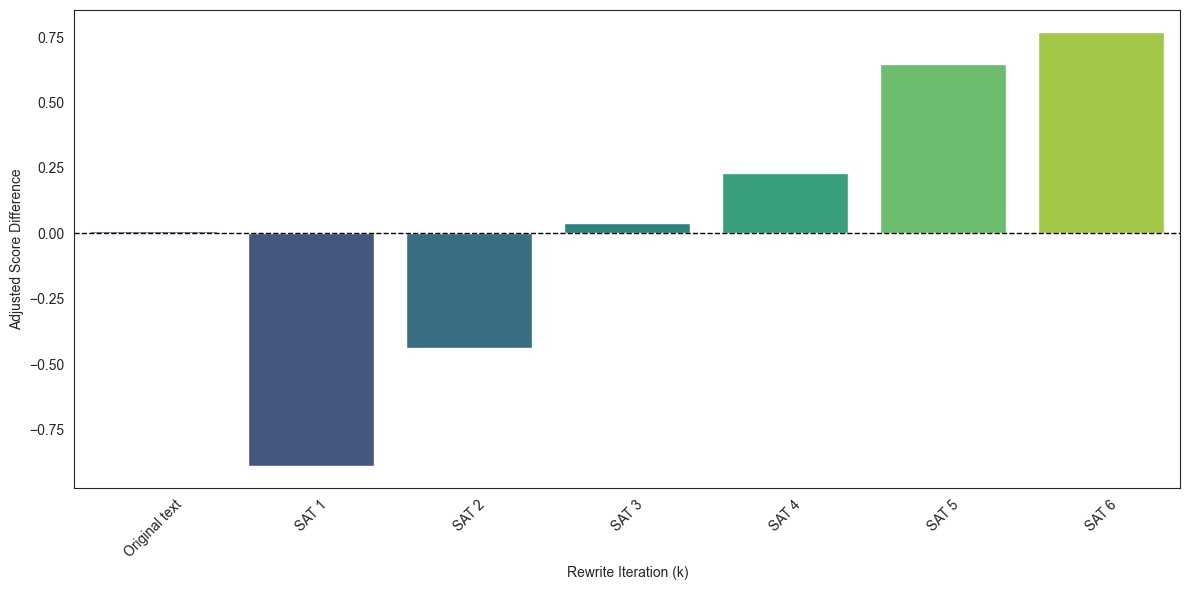

In [24]:
# --- Compute adjusted score differences ---
df_viz = results_df.copy()

CORRECTION_INDEX = {
    0: 1.0,
    1: 1.0,
    2: 1.0,
    3: 1.0,
    4: 1.0,
    5: 1.0,
    6: 1.0
}

df_viz["correction_factor"] = df_viz["k"].map(CORRECTION_INDEX)
df_viz["score_diff"] = (
    df_viz["score_high_full"] - df_viz["true_score"]
) * df_viz["correction_factor"]

diff_by_k = (
    df_viz
    .groupby("k", as_index=False)["score_diff"]
    .mean()
)

diff_by_k["label"] = diff_by_k["k"].map(K_LABELS)

# --- Plot ---
plt.figure(figsize=FIG_SIZE)

sns.barplot(
    data=diff_by_k,
    x="label",
    y="score_diff",
    palette="viridis"
)

plt.xlabel("Rewrite Iteration (k)")
plt.ylabel("Adjusted Score Difference")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/score_diff_by_k.pdf")
plt.show()


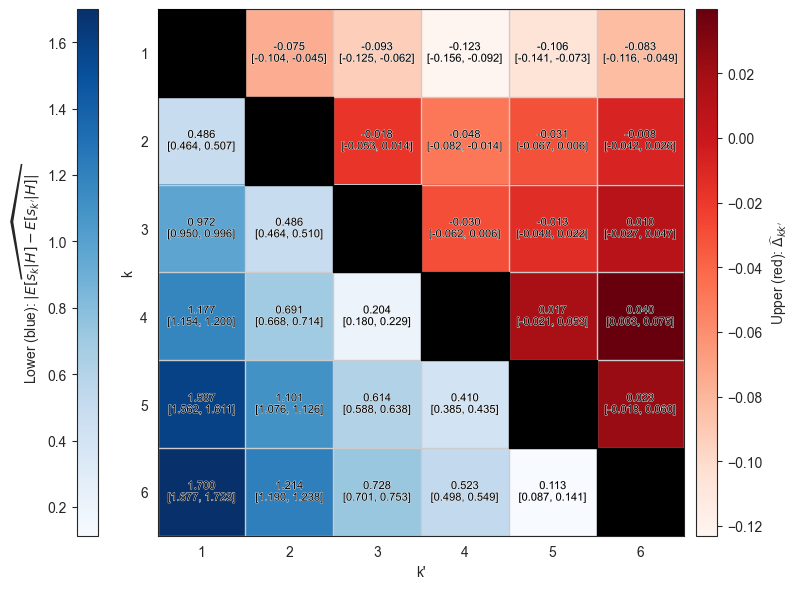

Saved figure: ../../output/ses_upper_red_lower_blue_two_colorbars.pdf


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ----------------------------
# CONFIG
# ----------------------------
K_COL     = "k"
SES_COL   = "low_SES"          # True = Low SES, False = High SES
SCORE_COL = "score_high_full"

K_MIN, K_MAX = 1, 6

# If each unit i appears multiple times across k, set ID_COL and you'll get a cluster bootstrap by i.
ID_COL = None   # e.g. "person_id" or "student_id"

B = 2000
ALPHA = 0.05
RANDOM_SEED = 0

# Safe defaults if not defined elsewhere
try:
    SAVE_DIR
except NameError:
    SAVE_DIR = "."

try:
    FIG_SIZE
except NameError:
    FIG_SIZE = (9, 7)

os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------
# Helpers
# ----------------------------
def compute_moments(df: pd.DataFrame):
    """
    Returns:
      ks (K,)
      mean_H (K,)
      mean_L (K,)
      Delta (K,K) where Delta[i,j] = (H_i-H_j) - (L_i-L_j)
      Hdiff (K,K) where Hdiff[i,j] = H_i - H_j
    """
    df = df.copy()
    df["ses_group"] = df[SES_COL].map({False: "H", True: "L"})
    ks = np.arange(K_MIN, K_MAX + 1)

    mean_tbl = (
        df.pivot_table(index=K_COL, columns="ses_group", values=SCORE_COL, aggfunc="mean")
          .reindex(ks)
    )

    if not {"H", "L"}.issubset(mean_tbl.columns):
        raise ValueError(f"Missing at least one SES group. Found: {list(mean_tbl.columns)}")

    if mean_tbl[["H", "L"]].isna().any().any():
        missing_rows = mean_tbl[["H", "L"]].isna().any(axis=1).to_numpy()
        miss_ks = ks[missing_rows]
        raise ValueError(f"Missing mean(s) for some k: {miss_ks}. Ensure both SES groups exist for every k.")

    mean_H = mean_tbl["H"].to_numpy()
    mean_L = mean_tbl["L"].to_numpy()

    Hdiff = mean_H[:, None] - mean_H[None, :]
    Ldiff = mean_L[:, None] - mean_L[None, :]
    Delta = Hdiff - Ldiff

    return ks, mean_H, mean_L, Delta, Hdiff

def cluster_bootstrap_sample(df: pd.DataFrame, id_col: str, rng: np.random.Generator):
    ids = df[id_col].dropna().unique()
    if len(ids) == 0:
        raise ValueError(f"No non-missing IDs found in {id_col}.")
    samp_ids = rng.choice(ids, size=len(ids), replace=True)
    return pd.concat([df[df[id_col] == sid] for sid in samp_ids], ignore_index=True)

def row_bootstrap_sample(df: pd.DataFrame, rng: np.random.Generator):
    n = len(df)
    idx = rng.integers(0, n, size=n)
    return df.iloc[idx].copy()

# ----------------------------
# Compute point estimates
# ----------------------------
df = results_df.copy()  # assumes results_df exists
ks, mean_H, mean_L, Delta_hat, Hdiff_hat = compute_moments(df)
K = len(ks)

upp = np.triu_indices(K, k=1)   # k<k'
low = np.tril_indices(K, k=-1)  # k>k'

# ----------------------------
# Bootstrap (for CIs shown in text)
# ----------------------------
rng = np.random.default_rng(RANDOM_SEED)

boot_Delta = np.empty((B, len(upp[0])), dtype=float)
boot_Hdiff = np.empty((B, len(low[0])), dtype=float)

for b in range(B):
    df_b = cluster_bootstrap_sample(df, ID_COL, rng) if ID_COL else row_bootstrap_sample(df, rng)
    _, _, _, Delta_b, Hdiff_b = compute_moments(df_b)

    boot_Delta[b, :] = Delta_b[upp]
    boot_Hdiff[b, :] = Hdiff_b[low]

q_lo, q_hi = ALPHA/2, 1 - ALPHA/2
Delta_lo = np.quantile(boot_Delta, q_lo, axis=0)
Delta_hi = np.quantile(boot_Delta, q_hi, axis=0)

Hdiff_lo = np.quantile(boot_Hdiff, q_lo, axis=0)
Hdiff_hi = np.quantile(boot_Hdiff, q_hi, axis=0)

# ----------------------------
# Build annotation strings
# ----------------------------
annot = np.full((K, K), "", dtype=object)

# Upper: Delta with CI
for idx, (i, j) in enumerate(zip(upp[0], upp[1])):
    est = Delta_hat[i, j]
    lo  = Delta_lo[idx]
    hi  = Delta_hi[idx]
    annot[i, j] = f"{est:.3f}\n[{lo:.3f}, {hi:.3f}]"

# Lower: High-SES difference with CI: E[s_k|H]-E[s_k'|H]
for idx, (i, j) in enumerate(zip(low[0], low[1])):
    est = Hdiff_hat[i, j]
    lo  = Hdiff_lo[idx]
    hi  = Hdiff_hi[idx]
    annot[i, j] = f"{est:.3f}\n[{lo:.3f}, {hi:.3f}]"

# ----------------------------
# ONLY: Plot the second matrix (red upper, blue lower, 2 colorbars)
# ----------------------------
upper_mat = np.full((K, K), np.nan, dtype=float)   # colors for Delta (upper)
lower_mat = np.full((K, K), np.nan, dtype=float)   # colors for |Hdiff| (lower)

upper_mat[upp] = Delta_hat[upp]
lower_mat[low] = np.abs(Hdiff_hat[low])  # intensity by magnitude; sign is in text

upper_masked = np.ma.masked_invalid(upper_mat)
lower_masked = np.ma.masked_invalid(lower_mat)

# Colormaps with transparent NaNs so overlays don't clash
cmap_upper = plt.cm.Reds.copy()
cmap_upper.set_bad((1, 1, 1, 0))  # transparent

cmap_lower = plt.cm.Blues.copy()
cmap_lower.set_bad((1, 1, 1, 0))  # transparent

figsize = FIG_SIZE if isinstance(FIG_SIZE, tuple) else (9, 7)
fig, ax = plt.subplots(figsize=figsize)

# Draw overlays
im_upper = ax.imshow(upper_masked, cmap=cmap_upper, aspect="equal")
im_lower = ax.imshow(lower_masked, cmap=cmap_lower, aspect="equal")

# Axes ticks/labels
ax.set_xticks(np.arange(K))
ax.set_yticks(np.arange(K))
ax.set_xticklabels(ks)
ax.set_yticklabels(ks)
ax.set_xlabel("k'")
ax.set_ylabel("k")

# Table grid
ax.set_xticks(np.arange(-0.5, K, 1), minor=True)
ax.set_yticks(np.arange(-0.5, K, 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbars on both sides
divider = make_axes_locatable(ax)

# Left colorbar for lower triangle (blue)
cax_left = divider.append_axes("left", size="4%", pad=0.6)
cb_left = fig.colorbar(im_lower, cax=cax_left)
cb_left.set_label(r"Lower (blue): $|\widehat{E[s_k|H]-E[s_{k'}|H]}|$")
cax_left.yaxis.set_label_position("left")
cax_left.yaxis.tick_left()

# Right colorbar for upper triangle (red)
cax_right = divider.append_axes("right", size="4%", pad=0.12)
cb_right = fig.colorbar(im_upper, cax=cax_right)
cb_right.set_label(r"Upper (red): $\widehat{\Delta}_{kk'}$")

# Diagonal black boxes (on top)
for d in range(K):
    ax.add_patch(Rectangle((d - 0.5, d - 0.5), 1, 1,
                           facecolor="black", edgecolor="black",
                           linewidth=1, zorder=3))

# Text annotations (upper + lower)
for i in range(K):
    for j in range(K):
        if annot[i, j] != "":
            t = ax.text(j, i, annot[i, j],
                        ha="center", va="center",
                        fontsize=8, color="black", zorder=4)
            t.set_path_effects([pe.withStroke(linewidth=0.6, foreground="white")])

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, "ses_upper_red_lower_blue_two_colorbars.pdf")
plt.savefig(out_path)
plt.show()

print(f"Saved figure: {out_path}")


### Distribution of rewrites predicted score - high ranker

In [26]:
# Stable color map by label
_BASE = sns.color_palette("tab10", n_colors=len(K_LABELS))
COLOR_MAP = {K_LABELS[k]: _BASE[i] for i, k in enumerate(sorted(K_LABELS))}

def plot_k_kde(results_df, pred_col, out_png, scorer_note):
    df = results_df[[pred_col, "k"]].dropna().copy()
    df["k"] = df["k"].astype(int)
    df["k_label"] = df["k"].map(K_LABELS)
    df = df[df["k_label"].notna()]

    present = [K_LABELS[k] for k in sorted(df["k"].unique()) if k in K_LABELS]
    pal = [COLOR_MAP[l] for l in present]

    plt.figure(figsize=FIG_SIZE if "FIG_SIZE" in globals() else (8, 6))

    ax = sns.kdeplot(
        data=df,
        x=pred_col,
        hue="k_label",
        hue_order=present,
        palette=pal,
        common_norm=False,
        linewidth=2,
        clip=(1, 6),
    )
    ax.set_xlim(1, 6)
    ax.set_xlabel(f"Predicted Essay Score {scorer_note}")
    ax.set_ylabel("Density")

    # --- Fix existing legend instead of creating new one ---
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title("Version (k)")
        leg.set_bbox_to_anchor((1.02, 1))
        leg._loc = 2  # 'upper left'

    plt.tight_layout()
    plt.savefig(out_png)
    plt.show()

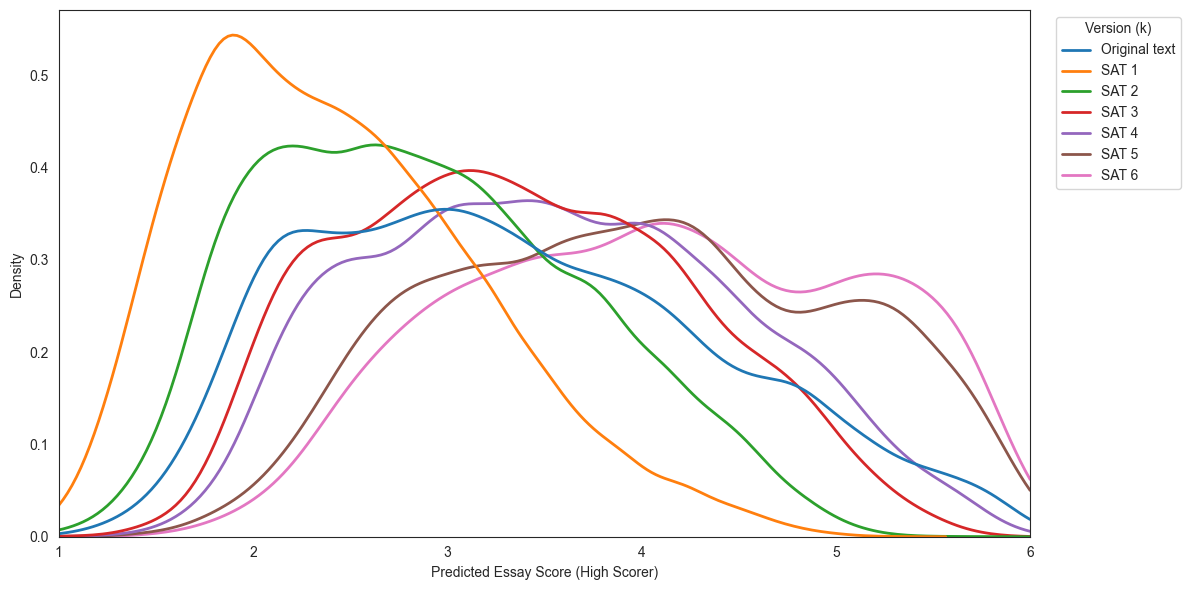

In [27]:
plot_k_kde(results_df, "score_high_full", f"{SAVE_DIR}predicted_scores_k_high_density.pdf", "(High Scorer)")

### Distribution of rewrites predicted score - low ranker

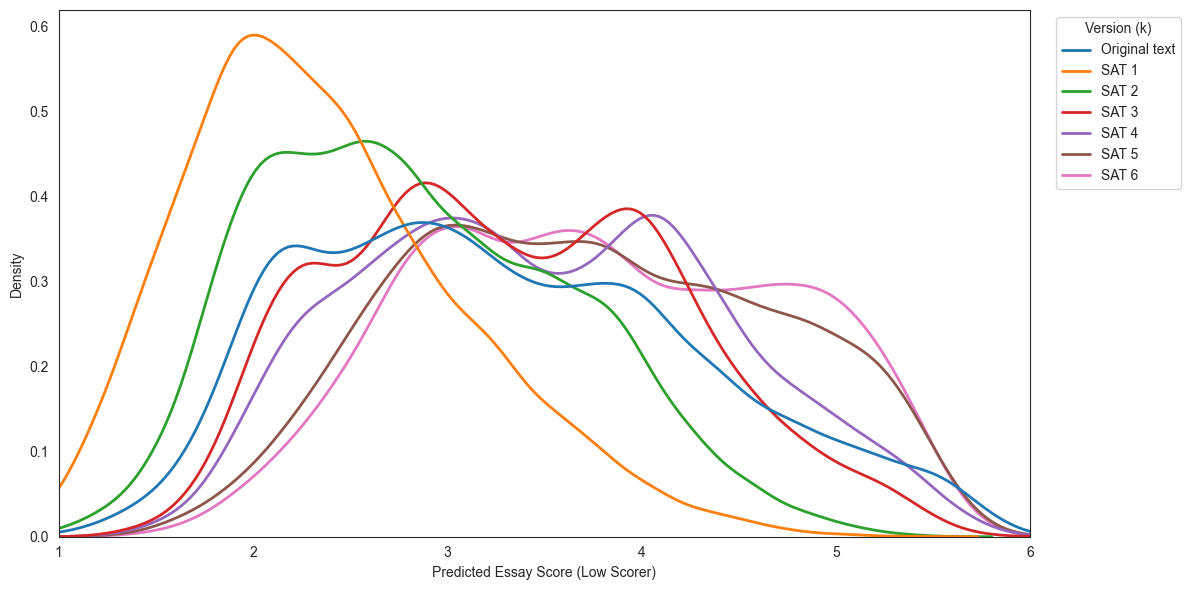

In [28]:
plot_k_kde(results_df, "score_low_full",  f"{SAVE_DIR}predicted_scores_k_low_density.pdf",  "(Low Scorer)")

### Bar graph - mean prediction (rewrite X SES)

/var/folders/xh/h3br85cj4574lr6srgb5hrgw0000gn/T/ipykernel_2312/3666882324.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/var/folders/xh/h3br85cj4574lr6srgb5hrgw0000gn/T/ipykernel_2312/3666882324.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


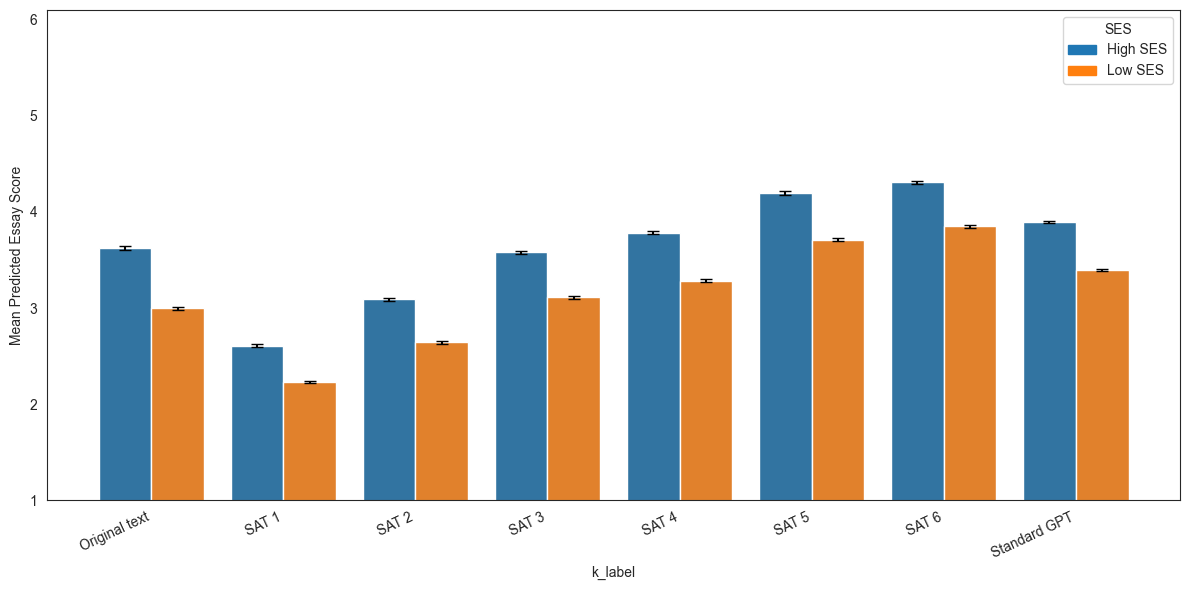

In [29]:
from scipy.stats import norm

# =========================
# --- Prep ---
# =========================
df = allRewrites.dropna(subset=["score_high_full", "low_SES", "k"]).copy()
df["k_label"] = df["k"].map(K_LABELS)

# =========================
# --- Aggregate: mean and standard error by k × SES ---
# =========================
agg = (
    df.groupby(["k_label", "low_SES"])["score_high_full"]
      .agg(["mean", "count", "std"])
      .reset_index()
)

agg["se"] = agg["std"] / np.sqrt(agg["count"])
z = norm.ppf(0.975)          # 95% CI critical value (~1.96)
agg["ci"] = z * agg["se"]    # half-width of 95% CI

# Ensure consistent ordering for plotting + errorbar alignment
agg["low_SES"] = agg["low_SES"].astype(int)
agg["k_label"] = pd.Categorical(agg["k_label"], categories=list(K_LABELS.values()), ordered=True)
agg = agg.sort_values(["k_label", "low_SES"]).reset_index(drop=True)

# =========================
# --- Plot bars (NO seaborn CI; we add our own) ---
# =========================
plt.figure(figsize=FIG_SIZE)
ax = sns.barplot(
    data=agg,
    x="k_label",
    y="mean",
    hue="low_SES",
    order=list(K_LABELS.values()),
    palette={0: "tab:blue", 1: "tab:orange"},
    ci=None,          # critical: don't let seaborn compute CIs
    dodge=True,
    legend=True
)

# =========================
# --- Add manual 95% CI error bars ---
#   We align errorbars to the bars seaborn drew by iterating containers.
# =========================
# ax.containers are in hue order (0 then 1) with one bar per x category
# Our agg is sorted by k_label then low_SES, so split rows by group:
agg0 = agg[agg["low_SES"] == 0].reset_index(drop=True)  # High SES
agg1 = agg[agg["low_SES"] == 1].reset_index(drop=True)  # Low SES

containers = ax.containers
if len(containers) >= 2:
    for bar, row in zip(containers[0], agg0.itertuples(index=False)):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.errorbar(x, y, yerr=row.ci, color="black", capsize=4, linewidth=1.5)

    for bar, row in zip(containers[1], agg1.itertuples(index=False)):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.errorbar(x, y, yerr=row.ci, color="black", capsize=4, linewidth=1.5)
else:
    # Fallback (shouldn't happen): compute positions from bars directly
    for bar, row in zip(ax.patches, agg.itertuples(index=False)):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.errorbar(x, y, yerr=row.ci, color="black", capsize=4, linewidth=1.5)

# =========================
# --- Styling ---
# =========================
# ax.set_xlabel("Rewrite Type (k)")
ax.set_ylabel("Mean Predicted Essay Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_yticks(np.arange(1, 7, 1))
ax.set_ylim(1, 6.1)

ax.legend(
    handles=[
        mpatches.Patch(color="tab:blue", label="High SES"),
        mpatches.Patch(color="tab:orange", label="Low SES"),
    ],
    title="SES",
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}rewrite_k_mean_all_CI.pdf")
plt.show()